# LSTM

In [15]:
# ============================================================
# LSTM Forecasting for WTI Futures — Multi-Horizon
# ============================================================
# Horizons: 1-day, 5-day (weekly), 20-day (monthly) log returns
#
# - FRED-MD macro data + WTI daily price
# - Strict anti-leakage macro shifting (month m → available m+1)
# - Aligned to trading days only
# - 3D sequence input: (samples, lookback=30, n_features)
# - TimeSeriesSplit CV (5-fold) for hyperparameter selection
# - StandardScaler (fit on train only)
# - PyTorch primary, TensorFlow/Keras fallback
# ============================================================

from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import warnings
import itertools
import os
import time
from abc import ABC, abstractmethod
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

In [16]:
# ============================================================
# Framework detection
# ============================================================
FRAMEWORK = None
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    FRAMEWORK = "pytorch"
except ImportError:
    try:
        os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
        import tensorflow as tf
        from tensorflow import keras
        FRAMEWORK = "keras"
    except ImportError:
        raise ImportError(
            "Neither PyTorch nor TensorFlow is installed.\n"
            "  pip install torch\n  pip install tensorflow"
        )
print(f"[LSTM] Using framework: {FRAMEWORK}")

[LSTM] Using framework: pytorch


In [17]:
# ============================================================
# Base Forecast Model
# ============================================================
class BaseForecastModel(ABC):
    def __init__(self, task_type: str):
        self.task_type = task_type

    @abstractmethod
    def fit(self, *args, **kwargs):
        pass

    @abstractmethod
    def predict(self, X):
        pass

    @abstractmethod
    def evaluate(self, X, y):
        pass

    @abstractmethod
    def save(self, filepath: str):
        pass

    @abstractmethod
    def load(self, filepath: str):
        pass


In [18]:
# ============================================================
# Metrics
# ============================================================
def rmse(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def mae(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.mean(np.abs(y - yhat)))

def r2(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum((y - yhat) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

def directional_accuracy(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.mean(np.sign(y) == np.sign(yhat)))


In [19]:
# ============================================================
# Data Helpers (STRICT leakage control)
# ============================================================
def load_macro_monthly(path: Path, features: list[str]) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]
    if missing:
        print(f"[WARN] Missing macro columns (skipped): {missing}")
    return df[keep].copy()


def load_price(path: Path) -> pd.Series:
    px = pd.read_csv(path, parse_dates=["Date"])
    return px.set_index("Date")["Price"].sort_index()


def make_target(price: pd.Series, horizon: int = 1) -> pd.Series:
    """
    h-day-ahead log return: y_t = log(P_{t+h}) - log(P_t)

    horizon=1  → next-day return
    horizon=5  → next-week return (5 trading days)
    horizon=20 → next-month return (20 trading days)
    """
    price = price.astype(float)
    return (np.log(price.shift(-horizon)) - np.log(price)).rename("y")

In [20]:
# ============================================================
# 3D Sequence Builder (multi-horizon aware)
# ============================================================
def build_sequences(
    macro_file: Path,
    price_file: Path,
    features: list[str],
    lookback: int = 30,
    horizon: int = 1,
    train_end: str = "2014-12-31",
    val_end: str = "2024-12-31",
):
    """
    Build 3D sliding-window sequences for LSTM.

    Returns:
        X_train, y_train, X_val, y_val, X_test, y_test  (numpy)
        dates_train, dates_val, dates_test               (DatetimeIndex)
        feat_cols                                        (list[str])

    X shape: (n_samples, lookback, n_features)
    Target: h-day-ahead log return (non-overlapping assignment,
            but consecutive samples DO share overlapping target windows
            when horizon > 1 — this is standard in the literature but
            should be noted in writeup).
    """
    # --- Load & shift macro (anti-leakage) ---
    macro_m = load_macro_monthly(macro_file, features)
    macro_m.index = macro_m.index + pd.offsets.MonthBegin(1)

    # --- Load price (trading days) ---
    price = load_price(price_file)

    # --- Align macro to trading days ---
    macro_d = macro_m.reindex(price.index, method="ffill")

    # --- Base frame ---
    base = macro_d.join(price, how="inner").dropna()
    base["ret_1d"] = np.log(base["Price"]).diff()
    base = base.dropna()

    # Feature columns
    feat_cols = [c for c in features if c in base.columns] + ["ret_1d"]

    feature_data = base[feat_cols].values      # (T, n_features)
    target_series = make_target(base["Price"], horizon=horizon)
    target_data = target_series.values
    dates = base.index

    # --- Sliding window ---
    X_list, y_list, d_list = [], [], []
    for i in range(lookback, len(feature_data)):
        if i < len(target_data) and np.isfinite(target_data[i]):
            X_list.append(feature_data[i - lookback : i])
            y_list.append(target_data[i])
            d_list.append(dates[i])

    X_all = np.array(X_list, dtype=np.float32)
    y_all = np.array(y_list, dtype=np.float32)
    d_all = pd.DatetimeIndex(d_list)

    # --- Split ---
    train_end_ts = pd.Timestamp(train_end)
    val_end_ts   = pd.Timestamp(val_end)

    tr = d_all <= train_end_ts
    va = (d_all > train_end_ts) & (d_all <= val_end_ts)
    te = d_all > val_end_ts

    return (
        X_all[tr], y_all[tr],
        X_all[va], y_all[va],
        X_all[te], y_all[te],
        d_all[tr], d_all[va], d_all[te],
        feat_cols,
    )

In [21]:
# ============================================================
# 3D Scaler
# ============================================================
def scale_3d(X_train, X_val=None, X_test=None):
    n, T, F = X_train.shape
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, F))

    def _tx(X):
        return scaler.transform(X.reshape(-1, F)).reshape(X.shape[0], T, F).astype(np.float32)

    out = [_tx(X_train)]
    if X_val is not None:
        out.append(_tx(X_val))
    if X_test is not None:
        out.append(_tx(X_test))
    return tuple(out) + (scaler,)

In [22]:
# ============================================================
# PyTorch Backend
# ============================================================
if FRAMEWORK == "pytorch":

    class LSTMNet(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers, dropout):
            super().__init__()
            self.lstm = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0.0,
                batch_first=True,
            )
            self.head = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(hidden_size, 1),
            )

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.head(out[:, -1, :]).squeeze(-1)

    def _train_lstm_pytorch(
        X_train, y_train, X_val, y_val,
        hidden_size, num_layers, dropout, lr,
        batch_size, epochs, patience, device,
    ):
        input_size = X_train.shape[2]
        model = LSTMNet(input_size, hidden_size, num_layers, dropout).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
        criterion = nn.MSELoss()

        train_ds = TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.float32),
        )
        val_ds = TensorDataset(
            torch.tensor(X_val, dtype=torch.float32),
            torch.tensor(y_val, dtype=torch.float32),
        )
        train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
        val_dl   = DataLoader(val_ds,   batch_size=batch_size * 2, shuffle=False)

        best_val_loss, best_state, wait = np.inf, None, 0

        for epoch in range(1, epochs + 1):
            model.train()
            for xb, yb in train_dl:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            model.eval()
            preds = []
            with torch.no_grad():
                for xb, _ in val_dl:
                    preds.append(model(xb.to(device)).cpu().numpy())
            val_loss = float(np.sqrt(np.mean((y_val - np.concatenate(preds)) ** 2)))

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    break

        if best_state:
            model.load_state_dict(best_state)
        model.eval()
        return model, best_val_loss

    def _predict_pytorch(model, X_scaled, device):
        model.eval()
        with torch.no_grad():
            xt = torch.tensor(X_scaled, dtype=torch.float32).to(device)
            return model(xt).cpu().numpy()

    def _save_model_pytorch(model, best_params):
        return {
            "state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
            "config": {
                "input_size": model.lstm.input_size,
                "hidden_size": best_params["hidden_size"],
                "num_layers": best_params["num_layers"],
                "dropout": best_params["dropout"],
            },
        }

    def _load_model_pytorch(model_data, device):
        cfg = model_data["config"]
        model = LSTMNet(
            cfg["input_size"], cfg["hidden_size"],
            cfg["num_layers"], cfg["dropout"],
        ).to(device)
        model.load_state_dict(model_data["state_dict"])
        model.eval()
        return model

    train_lstm   = _train_lstm_pytorch
    predict_fn   = _predict_pytorch
    save_model_fn = _save_model_pytorch
    load_model_fn = _load_model_pytorch

# ============================================================
# Keras Backend
# ============================================================
elif FRAMEWORK == "keras":

    def _build_keras_model(input_shape, hidden_size, num_layers, dropout, lr):
        model = keras.Sequential()
        for i in range(num_layers):
            return_seq = (i < num_layers - 1)
            model.add(keras.layers.LSTM(
                hidden_size,
                return_sequences=return_seq,
                input_shape=input_shape if i == 0 else None,
            ))
            model.add(keras.layers.Dropout(dropout))
        model.add(keras.layers.Dense(1))
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
        return model

    def _train_lstm_keras(
        X_train, y_train, X_val, y_val,
        hidden_size, num_layers, dropout, lr,
        batch_size, epochs, patience, device,
    ):
        input_shape = (X_train.shape[1], X_train.shape[2])
        model = _build_keras_model(input_shape, hidden_size, num_layers, dropout, lr)
        es = keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience, restore_best_weights=True
        )
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs, batch_size=batch_size,
            callbacks=[es], verbose=0,
        )
        val_pred = model.predict(X_val, verbose=0).flatten()
        val_rmse = float(np.sqrt(np.mean((y_val - val_pred) ** 2)))
        return model, val_rmse

    def _predict_keras(model, X_scaled, device):
        return model.predict(X_scaled, verbose=0).flatten()

    def _save_model_keras(model, best_params):
        return {
            "weights": model.get_weights(),
            "config": {
                "input_shape": (model.input_shape[1], model.input_shape[2]),
                "hidden_size": best_params["hidden_size"],
                "num_layers": best_params["num_layers"],
                "dropout": best_params["dropout"],
                "lr": best_params["lr"],
            },
        }

    def _load_model_keras(model_data, device):
        cfg = model_data["config"]
        model = _build_keras_model(
            cfg["input_shape"], cfg["hidden_size"],
            cfg["num_layers"], cfg["dropout"], cfg["lr"],
        )
        model.set_weights(model_data["weights"])
        return model

    train_lstm    = _train_lstm_keras
    predict_fn    = _predict_keras
    save_model_fn = _save_model_keras
    load_model_fn = _load_model_keras

In [23]:
# ============================================================
# LSTM Forecast Model (follows BaseForecastModel)
# ============================================================
class LSTMForecastModel(BaseForecastModel):
    """
    LSTM for WTI log-return forecasting at configurable horizons.

    Hyperparameter search via TimeSeriesSplit CV.
    Final model retrained on full training data with last 10%
    held out for early stopping.
    """

    def __init__(
        self,
        horizon: int = 1,
        lookback: int = 30,
        n_splits: int = 5,
        epochs: int = 200,
        patience: int = 20,
        batch_size: int = 128,
        device: str = None,
        # Hyperparameter grid
        hidden_sizes: list[int]    = None,
        num_layers_list: list[int] = None,
        dropouts: list[float]      = None,
        learning_rates: list[float] = None,
    ):
        super().__init__("regression")
        self.horizon      = horizon
        self.lookback     = lookback
        self.n_splits     = n_splits
        self.epochs       = epochs
        self.patience     = patience
        self.batch_size   = batch_size

        if FRAMEWORK == "pytorch":
            self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = "cpu"

        # Default grid (24 configs)
        self.hidden_sizes    = hidden_sizes    or [32, 64, 128]
        self.num_layers_list = num_layers_list or [1, 2]
        self.dropouts        = dropouts        or [0.1, 0.3]
        self.learning_rates  = learning_rates  or [1e-3, 5e-4]

        # Populated by fit()
        self.model_       = None
        self.scaler_      = None
        self.best_params_ = None
        self.cv_results_  = []
        self.feature_names_ = None

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        grid = list(itertools.product(
            self.hidden_sizes,
            self.num_layers_list,
            self.dropouts,
            self.learning_rates,
        ))

        print(f"\n[LSTM h={self.horizon}] CV grid search: {len(grid)} configs × "
              f"{self.n_splits} folds = {len(grid) * self.n_splits} fits")
        best_rmse = np.inf
        best_cfg  = None

        for idx, (hs, nl, do, lr) in enumerate(grid):
            fold_rmses = []
            for tr_idx, va_idx in tscv.split(X_train):
                Xtr, Xva = X_train[tr_idx], X_train[va_idx]
                ytr, yva = y_train[tr_idx], y_train[va_idx]
                Xtr_s, Xva_s, _ = scale_3d(Xtr, Xva)

                _, val_rmse = train_lstm(
                    Xtr_s, ytr, Xva_s, yva,
                    hidden_size=hs, num_layers=nl, dropout=do, lr=lr,
                    batch_size=self.batch_size, epochs=self.epochs,
                    patience=self.patience, device=self.device,
                )
                fold_rmses.append(val_rmse)

            mean_rmse = np.mean(fold_rmses)
            cfg = {"hidden_size": hs, "num_layers": nl,
                   "dropout": do, "lr": lr}
            self.cv_results_.append({**cfg, "cv_rmse": mean_rmse})
            print(f"  [{idx+1:2d}/{len(grid)}] hs={hs:3d} nl={nl} "
                  f"do={do:.1f} lr={lr:.0e} → CV RMSE: {mean_rmse:.6f}")

            if mean_rmse < best_rmse:
                best_rmse = mean_rmse
                best_cfg  = cfg

        self.best_params_ = {**best_cfg, "cv_rmse": best_rmse}
        print(f"[LSTM h={self.horizon}] Best: {self.best_params_}")

        # --- Final retraining ---
        n = len(X_train)
        split = int(n * 0.9)
        Xtr_f, Xva_f = X_train[:split], X_train[split:]
        ytr_f, yva_f = y_train[:split], y_train[split:]

        _, T, F = X_train.shape
        self.scaler_ = StandardScaler()
        self.scaler_.fit(X_train.reshape(-1, F))

        Xtr_s = self.scaler_.transform(Xtr_f.reshape(-1, F)).reshape(len(Xtr_f), T, F).astype(np.float32)
        Xva_s = self.scaler_.transform(Xva_f.reshape(-1, F)).reshape(len(Xva_f), T, F).astype(np.float32)

        self.model_, _ = train_lstm(
            Xtr_s, ytr_f, Xva_s, yva_f,
            hidden_size=best_cfg["hidden_size"],
            num_layers=best_cfg["num_layers"],
            dropout=best_cfg["dropout"],
            lr=best_cfg["lr"],
            batch_size=self.batch_size,
            epochs=self.epochs,
            patience=self.patience,
            device=self.device,
        )
        print(f"[LSTM h={self.horizon}] Final model trained.\n")
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        n, T, F = X.shape
        X_s = self.scaler_.transform(X.reshape(-1, F)).reshape(n, T, F).astype(np.float32)
        return predict_fn(self.model_, X_s, self.device)

    def evaluate(self, X: np.ndarray, y: np.ndarray) -> dict:
        p = self.predict(X)
        return {
            "rmse":  rmse(y, p),
            "mae":   mae(y, p),
            "r2":    r2(y, p),
            "directional_acc": directional_accuracy(y, p),
        }

    def save(self, path: str):
        state = {
            "framework":      FRAMEWORK,
            "horizon":        self.horizon,
            "best_params_":   self.best_params_,
            "cv_results_":    self.cv_results_,
            "scaler_":        self.scaler_,
            "feature_names_": self.feature_names_,
            "lookback":       self.lookback,
            "model_data":     save_model_fn(self.model_, self.best_params_)
                              if self.model_ is not None else None,
        }
        with open(path, "wb") as f:
            pickle.dump(state, f)
        print(f"[LSTM h={self.horizon}] Saved → {path}")

    def load(self, path: str):
        with open(path, "rb") as f:
            state = pickle.load(f)
        self.horizon        = state.get("horizon", 1)
        self.best_params_   = state["best_params_"]
        self.cv_results_    = state["cv_results_"]
        self.scaler_        = state["scaler_"]
        self.feature_names_ = state.get("feature_names_")
        self.lookback       = state.get("lookback", 30)

        saved_fw = state.get("framework", FRAMEWORK)
        if saved_fw != FRAMEWORK:
            print(f"[WARN] Saved with {saved_fw}, loading with {FRAMEWORK}")

        if state.get("model_data"):
            self.model_ = load_model_fn(state["model_data"], self.device)
        print(f"[LSTM h={self.horizon}] Loaded ← {path}")

In [24]:
# ============================================================
# EDA
# ============================================================
def run_eda(macro_file: Path, price_file: Path, features: list[str]):
    print("=" * 60)
    print("EDA: Macro + Price Data Inspection")
    print("=" * 60)

    macro_m = load_macro_monthly(macro_file, features)
    print(f"\n[Macro Monthly] Shape: {macro_m.shape}")
    print(f"  Date range : {macro_m.index.min()} → {macro_m.index.max()}")
    pct_miss = (macro_m.isna().sum() / len(macro_m) * 100).round(2)
    if pct_miss.any():
        print(f"  Missing (%):\n{pct_miss[pct_miss > 0].to_string()}")
    else:
        print("  Missing: None")

    price = load_price(price_file)
    print(f"\n[WTI Price] Length: {len(price)}")
    print(f"  Date range : {price.index.min()} → {price.index.max()}")
    print(f"  Missing    : {price.isna().sum()}")

    ret = np.log(price.astype(float)).diff().dropna()
    print(f"\n[Daily Log Returns] n={len(ret)}")
    print(f"  Mean : {ret.mean():.6f}")
    print(f"  Std  : {ret.std():.6f}")
    print(f"  Skew : {ret.skew():.4f}")
    print(f"  Kurt : {ret.kurtosis():.4f}")
    print(f"  Range: [{ret.min():.4f}, {ret.max():.4f}]")

    # Multi-horizon return stats
    for h in [1, 5, 20]:
        rh = (np.log(price.astype(float).shift(-h)) - np.log(price.astype(float))).dropna()
        print(f"\n[{h}-day Log Returns] n={len(rh)}")
        print(f"  Mean : {rh.mean():.6f}   Std: {rh.std():.6f}   "
              f"Skew: {rh.skew():.4f}   Kurt: {rh.kurtosis():.4f}")

    print("=" * 60)

In [25]:
# ============================================================
# RUN: Multi-Horizon Comparison
# ============================================================
if __name__ == "__main__":
    MACRO_FILE = Path("MD_Test/2025-12-MD.csv")
    PRICE_FILE = Path("Price/Price.csv")
    FEATURES = [
        "RPI","W875RX1","CMRMTSPLx","IPFPNSS","USWTRADE","USTRADE","BUSLOANS",
        "CONSPI","S&P 500","S&P PE ratio","FEDFUNDS","TB3MS","TB6MS","GS1","GS5",
        "GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM",
        "AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx",
        "PPICMM","UMCSENTx"
    ]

    HORIZONS = [1, 5, 20]

    # ---- EDA ----
    run_eda(MACRO_FILE, PRICE_FILE, FEATURES)

    # ---- Run each horizon ----
    all_results = {}

    for h in HORIZONS:
        print(f"\n{'='*60}")
        print(f"  HORIZON = {h} day(s)")
        print(f"{'='*60}")

        t0 = time.time()

        (Xtr, ytr, Xva, yva, Xte, yte,
         dtr, dva, dte, feat_cols) = build_sequences(
            MACRO_FILE, PRICE_FILE, FEATURES,
            lookback=30, horizon=h,
            train_end="2014-12-31", val_end="2024-12-31",
        )

        print(f"\nSequence shapes (h={h}):")
        print(f"  Train: X={Xtr.shape}  y={ytr.shape}  "
              f"({dtr.min().date()} → {dtr.max().date()})")
        print(f"  Val  : X={Xva.shape}  y={yva.shape}  "
              f"({dva.min().date()} → {dva.max().date()})")
        print(f"  Test : X={Xte.shape}  y={yte.shape}  "
              f"({dte.min().date()} → {dte.max().date()})")

        # Target stats
        print(f"  y_train — mean: {ytr.mean():.6f}  std: {ytr.std():.6f}")
        print(f"  y_val   — mean: {yva.mean():.6f}  std: {yva.std():.6f}")
        print(f"  y_test  — mean: {yte.mean():.6f}  std: {yte.std():.6f}")

        model = LSTMForecastModel(
            horizon=h,
            lookback=30,
            n_splits=5,
            epochs=200,
            patience=20,
            batch_size=128,
            hidden_sizes=[32, 64, 128],
            num_layers_list=[1, 2],
            dropouts=[0.1, 0.3],
            learning_rates=[1e-3, 5e-4],
        )
        model.feature_names_ = feat_cols
        model.fit(Xtr, ytr)

        val_metrics  = model.evaluate(Xva, yva)
        test_metrics = model.evaluate(Xte, yte)

        elapsed = time.time() - t0

        all_results[h] = {
            "best_params": model.best_params_,
            "val":  val_metrics,
            "test": test_metrics,
            "train_shape": Xtr.shape,
            "val_shape":   Xva.shape,
            "test_shape":  Xte.shape,
            "elapsed_min": elapsed / 60,
        }

        print(f"Validation (h={h}): {val_metrics}")
        print(f"Test       (h={h}): {test_metrics}")
        print(f"Time: {elapsed/60:.1f} min")

        model.save(f"lstm_wti_h{h}.pkl")

EDA: Macro + Price Data Inspection

[Macro Monthly] Shape: (803, 31)
  Date range : 1959-01-01 00:00:00 → 2025-11-01 00:00:00
  Missing (%):
RPI              0.25
W875RX1          0.25
CMRMTSPLx        0.25
CONSPI           0.25
S&P PE ratio     0.12
PPICMM           0.25
UMCSENTx        19.18

[WTI Price] Length: 10835
  Date range : 1983-03-31 00:00:00 → 2025-10-31 00:00:00
  Missing    : 0

[Daily Log Returns] n=10834
  Mean : 0.000068
  Std  : 0.025474
  Skew : -0.6516
  Kurt : 60.4536
  Range: [-0.5686, 0.5812]

[1-day Log Returns] n=10834
  Mean : 0.000068   Std: 0.025474   Skew: -0.6516   Kurt: 60.4536

[5-day Log Returns] n=10830
  Mean : 0.000330   Std: 0.052597   Skew: -0.8044   Kurt: 12.6432

[20-day Log Returns] n=10815
  Mean : 0.001251   Std: 0.100311   Skew: -0.5089   Kurt: 6.4150

  HORIZON = 1 day(s)

Sequence shapes (h=1):
  Train: X=(7953, 30, 32)  y=(7953,)  (1983-05-16 → 2014-12-31)
  Val  : X=(2635, 30, 32)  y=(2635,)  (2015-01-01 → 2024-12-31)
  Test : X=(215, 30

In [26]:
# ============================================================
# Comparison Table
# ============================================================
print("\n" + "=" * 80)
print("  LSTM MULTI-HORIZON COMPARISON")
print("=" * 80)

header = f"{'Horizon':>8} | {'Split':>5} | {'RMSE':>10} | {'MAE':>10} | {'R²':>10} | {'Dir Acc':>10}"
print(header)
print("-" * len(header))

for h in HORIZONS:
    r = all_results[h]
    for split_name, metrics in [("Val", r["val"]), ("Test", r["test"])]:
        print(f"  h={h:>2}d   | {split_name:>5} | "
                f"{metrics['rmse']:>10.6f} | "
                f"{metrics['mae']:>10.6f} | "
                f"{metrics['r2']:>10.6f} | "
                f"{metrics['directional_acc']:>10.4f}")
    print("-" * len(header))

print("\nBest configs:")
for h in HORIZONS:
    bp = all_results[h]["best_params"]
    print(f"  h={h:>2}d: hs={bp['hidden_size']}, nl={bp['num_layers']}, "
            f"do={bp['dropout']}, lr={bp['lr']}, "
            f"cv_rmse={bp['cv_rmse']:.6f}")

print("\nTimings:")
for h in HORIZONS:
    print(f"  h={h:>2}d: {all_results[h]['elapsed_min']:.1f} min")

# Save comparison
comp_df = []
for h in HORIZONS:
    for split_name, metrics in [("val", all_results[h]["val"]),
                                ("test", all_results[h]["test"])]:
        comp_df.append({"horizon": h, "split": split_name, **metrics})
comp_df = pd.DataFrame(comp_df)
comp_df.to_csv("lstm_horizon_comparison.csv", index=False)
print("\nComparison saved → lstm_horizon_comparison.csv")


  LSTM MULTI-HORIZON COMPARISON
 Horizon | Split |       RMSE |        MAE |         R² |    Dir Acc
--------------------------------------------------------------------
  h= 1d   |   Val |   0.031439 |   0.019526 |  -0.037192 |     0.4691
  h= 1d   |  Test |   0.022708 |   0.017491 |  -0.226709 |     0.4977
--------------------------------------------------------------------
  h= 5d   |   Val |   0.062612 |   0.044130 |  -0.125868 |     0.4569
  h= 5d   |  Test |   0.055916 |   0.044321 |  -0.318362 |     0.5261
--------------------------------------------------------------------
  h=20d   |   Val |   0.118070 |   0.082295 |  -0.063029 |     0.5188
  h=20d   |  Test |   0.070342 |   0.053280 |  -0.189952 |     0.6786
--------------------------------------------------------------------

Best configs:
  h= 1d: hs=128, nl=2, do=0.3, lr=0.001, cv_rmse=0.023616
  h= 5d: hs=128, nl=2, do=0.3, lr=0.001, cv_rmse=0.050281
  h=20d: hs=128, nl=2, do=0.1, lr=0.001, cv_rmse=0.093248

Timings:
  h

In [3]:
# ============================================================
# CELL 1: Imports & Setup
# ============================================================
import numpy as np
import pandas as pd
import pickle
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from scipy import stats
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 150,
})

COLORS = {
    'actual': '#1a1a2e', 'pred': '#e63946', 'fill': '#a8dadc',
    'pos': '#2a9d8f', 'neg': '#e76f51',
    'h1': '#264653', 'h5': '#2a9d8f', 'h20': '#e9c46a',
    'bar1': '#264653', 'bar2': '#e76f51',
}

MACRO_FILE = Path('MD_Test/2025-12-MD.csv')
PRICE_FILE = Path('Price/Price.csv')
FEATURES = [
    'RPI','W875RX1','CMRMTSPLx','IPFPNSS','USWTRADE','USTRADE','BUSLOANS',
    'CONSPI','S&P 500','S&P PE ratio','FEDFUNDS','TB3MS','TB6MS','GS1','GS5',
    'GS10','AAA','BAA','TB3SMFFM','TB6SMFFM','T1YFFM','T5YFFM','T10YFFM',
    'AAAFFM','BAAFFM','EXSZUSx','EXJPUSx','EXUSUKx','EXCAUSx',
    'PPICMM','UMCSENTx'
]
HORIZONS = [1, 5, 20]

print('Setup complete.')

Setup complete.


In [4]:
# ============================================================
# CELL 2: Data Loading & Prediction Helpers
# ============================================================

def load_macro_monthly(path, features):
    df = pd.read_csv(path, skiprows=[1]).rename(columns={'sasdate': 'date'})
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()
    keep = [c for c in features if c in df.columns]
    return df[keep].copy()

def load_price(path):
    px = pd.read_csv(path, parse_dates=['Date'])
    return px.set_index('Date')['Price'].sort_index()

def make_target(price, horizon=1):
    price = price.astype(float)
    return (np.log(price.shift(-horizon)) - np.log(price)).rename('y')

def build_sequences(macro_file, price_file, features, lookback=30, horizon=1,
                    train_end='2014-12-31', val_end='2024-12-31'):
    macro_m = load_macro_monthly(macro_file, features)
    macro_m.index = macro_m.index + pd.offsets.MonthBegin(1)
    price = load_price(price_file)
    macro_d = macro_m.reindex(price.index, method='ffill')
    base = macro_d.join(price, how='inner').dropna()
    base['ret_1d'] = np.log(base['Price']).diff()
    base = base.dropna()
    feat_cols = [c for c in features if c in base.columns] + ['ret_1d']
    feature_data = base[feat_cols].values
    target_data = make_target(base['Price'], horizon=horizon).values
    dates = base.index
    X_list, y_list, d_list = [], [], []
    for i in range(lookback, len(feature_data)):
        if i < len(target_data) and np.isfinite(target_data[i]):
            X_list.append(feature_data[i - lookback:i])
            y_list.append(target_data[i])
            d_list.append(dates[i])
    X_all = np.array(X_list, dtype=np.float32)
    y_all = np.array(y_list, dtype=np.float32)
    d_all = pd.DatetimeIndex(d_list)
    tr = d_all <= pd.Timestamp(train_end)
    va = (d_all > pd.Timestamp(train_end)) & (d_all <= pd.Timestamp(val_end))
    te = d_all > pd.Timestamp(val_end)
    return (X_all[tr], y_all[tr], X_all[va], y_all[va], X_all[te], y_all[te],
            d_all[tr], d_all[va], d_all[te], feat_cols)

class LSTMNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers,
                            dropout=dropout if num_layers > 1 else 0.0,
                            batch_first=True)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_size, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)

def load_model_and_predict(pkl_path, X_data, device='cpu'):
    with open(pkl_path, 'rb') as f:
        state = pickle.load(f)
    scaler = state['scaler_']
    cfg = state['model_data']['config']
    model = LSTMNet(cfg['input_size'], cfg['hidden_size'],
                    cfg['num_layers'], cfg['dropout']).to(device)
    model.load_state_dict(state['model_data']['state_dict'])
    model.eval()
    n, T, F = X_data.shape
    X_s = scaler.transform(X_data.reshape(-1, F)).reshape(n, T, F).astype(np.float32)
    with torch.no_grad():
        preds = model(torch.tensor(X_s).to(device)).cpu().numpy()
    return preds, state

def rmse(y, yhat): return float(np.sqrt(np.mean((y - yhat)**2)))
def mae(y, yhat): return float(np.mean(np.abs(y - yhat)))
def r2(y, yhat):
    ss_tot = np.sum((y - y.mean())**2)
    ss_res = np.sum((y - yhat)**2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan
def directional_accuracy(y, yhat):
    return float(np.mean(np.sign(y) == np.sign(yhat)))

print('Helpers loaded.')

Helpers loaded.


In [5]:
# ============================================================
# CELL 3: Load All Data & Predictions
# ============================================================

data = {}  # {horizon: {Xtr, ytr, Xva, yva, Xte, yte, dva, dte, pred_val, pred_test, state}}

for h in HORIZONS:
    pkl_path = f'lstm_wti_h{h}.pkl'
    if not Path(pkl_path).exists():
        print(f'[SKIP] {pkl_path} not found')
        continue

    (Xtr, ytr, Xva, yva, Xte, yte,
     dtr, dva, dte, feat_cols) = build_sequences(
        MACRO_FILE, PRICE_FILE, FEATURES,
        lookback=30, horizon=h,
        train_end='2014-12-31', val_end='2024-12-31',
    )

    pred_val, state = load_model_and_predict(pkl_path, Xva)
    pred_test, _ = load_model_and_predict(pkl_path, Xte)

    data[h] = {
        'Xtr': Xtr, 'ytr': ytr,
        'Xva': Xva, 'yva': yva,
        'Xte': Xte, 'yte': yte,
        'dtr': dtr, 'dva': dva, 'dte': dte,
        'pred_val': pred_val, 'pred_test': pred_test,
        'state': state, 'feat_cols': feat_cols,
    }

    print(f'h={h:2d}d  |  Val: {len(yva)} samples  |  Test: {len(yte)} samples  |  Loaded ✓')

print(f'\nAll {len(data)} horizons loaded.')

h= 1d  |  Val: 2635 samples  |  Test: 215 samples  |  Loaded ✓
h= 5d  |  Val: 2635 samples  |  Test: 211 samples  |  Loaded ✓
h=20d  |  Val: 2635 samples  |  Test: 196 samples  |  Loaded ✓

All 3 horizons loaded.


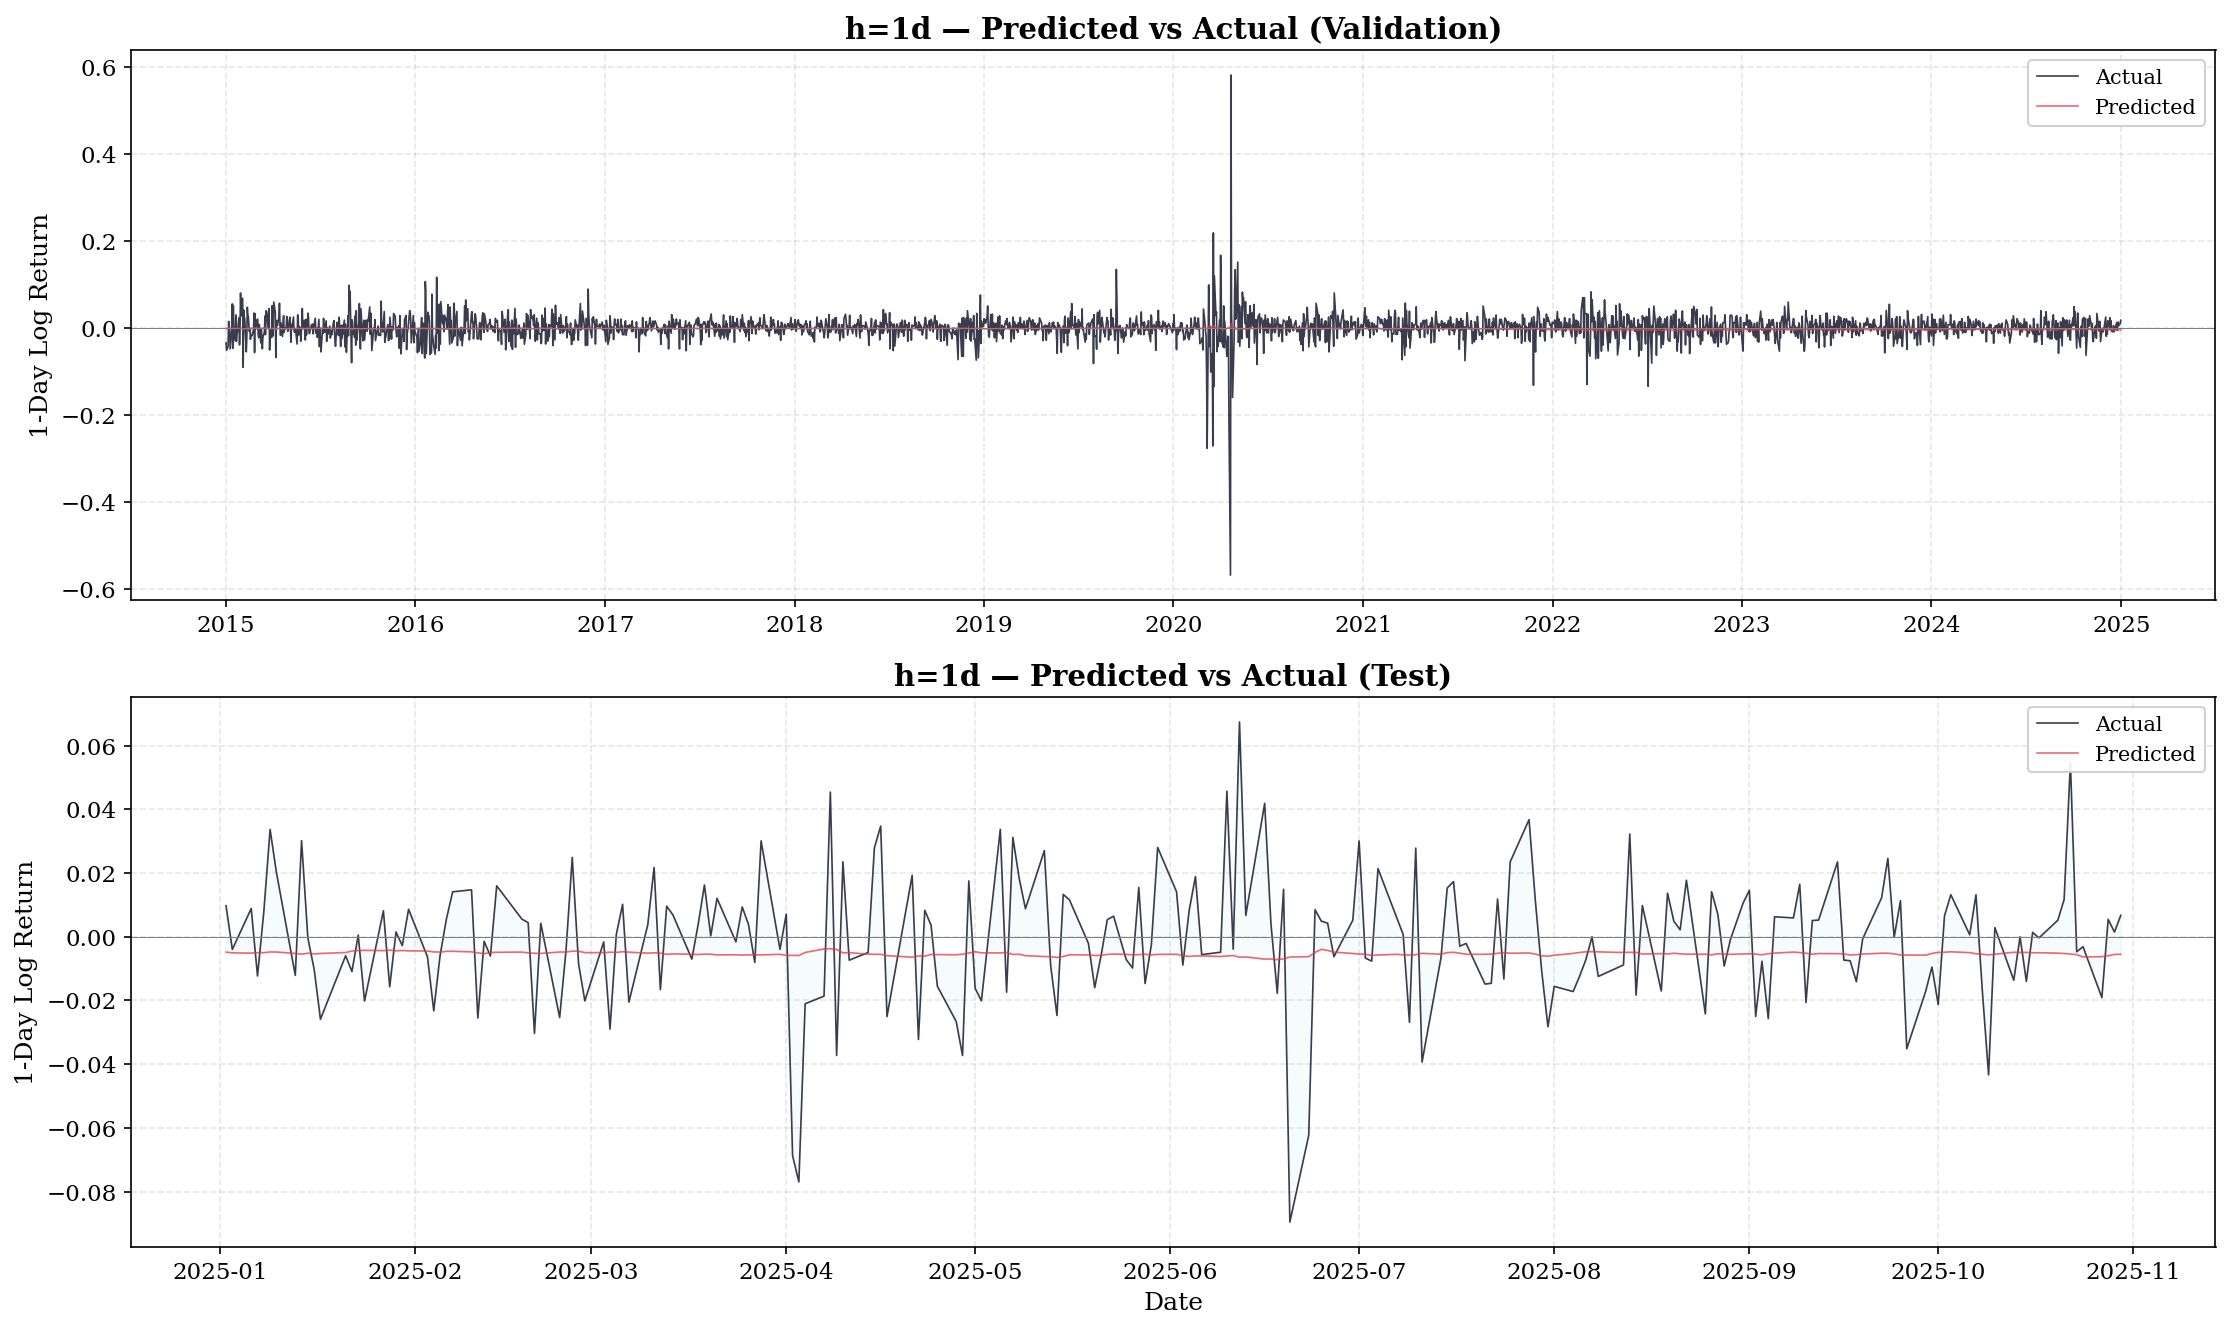

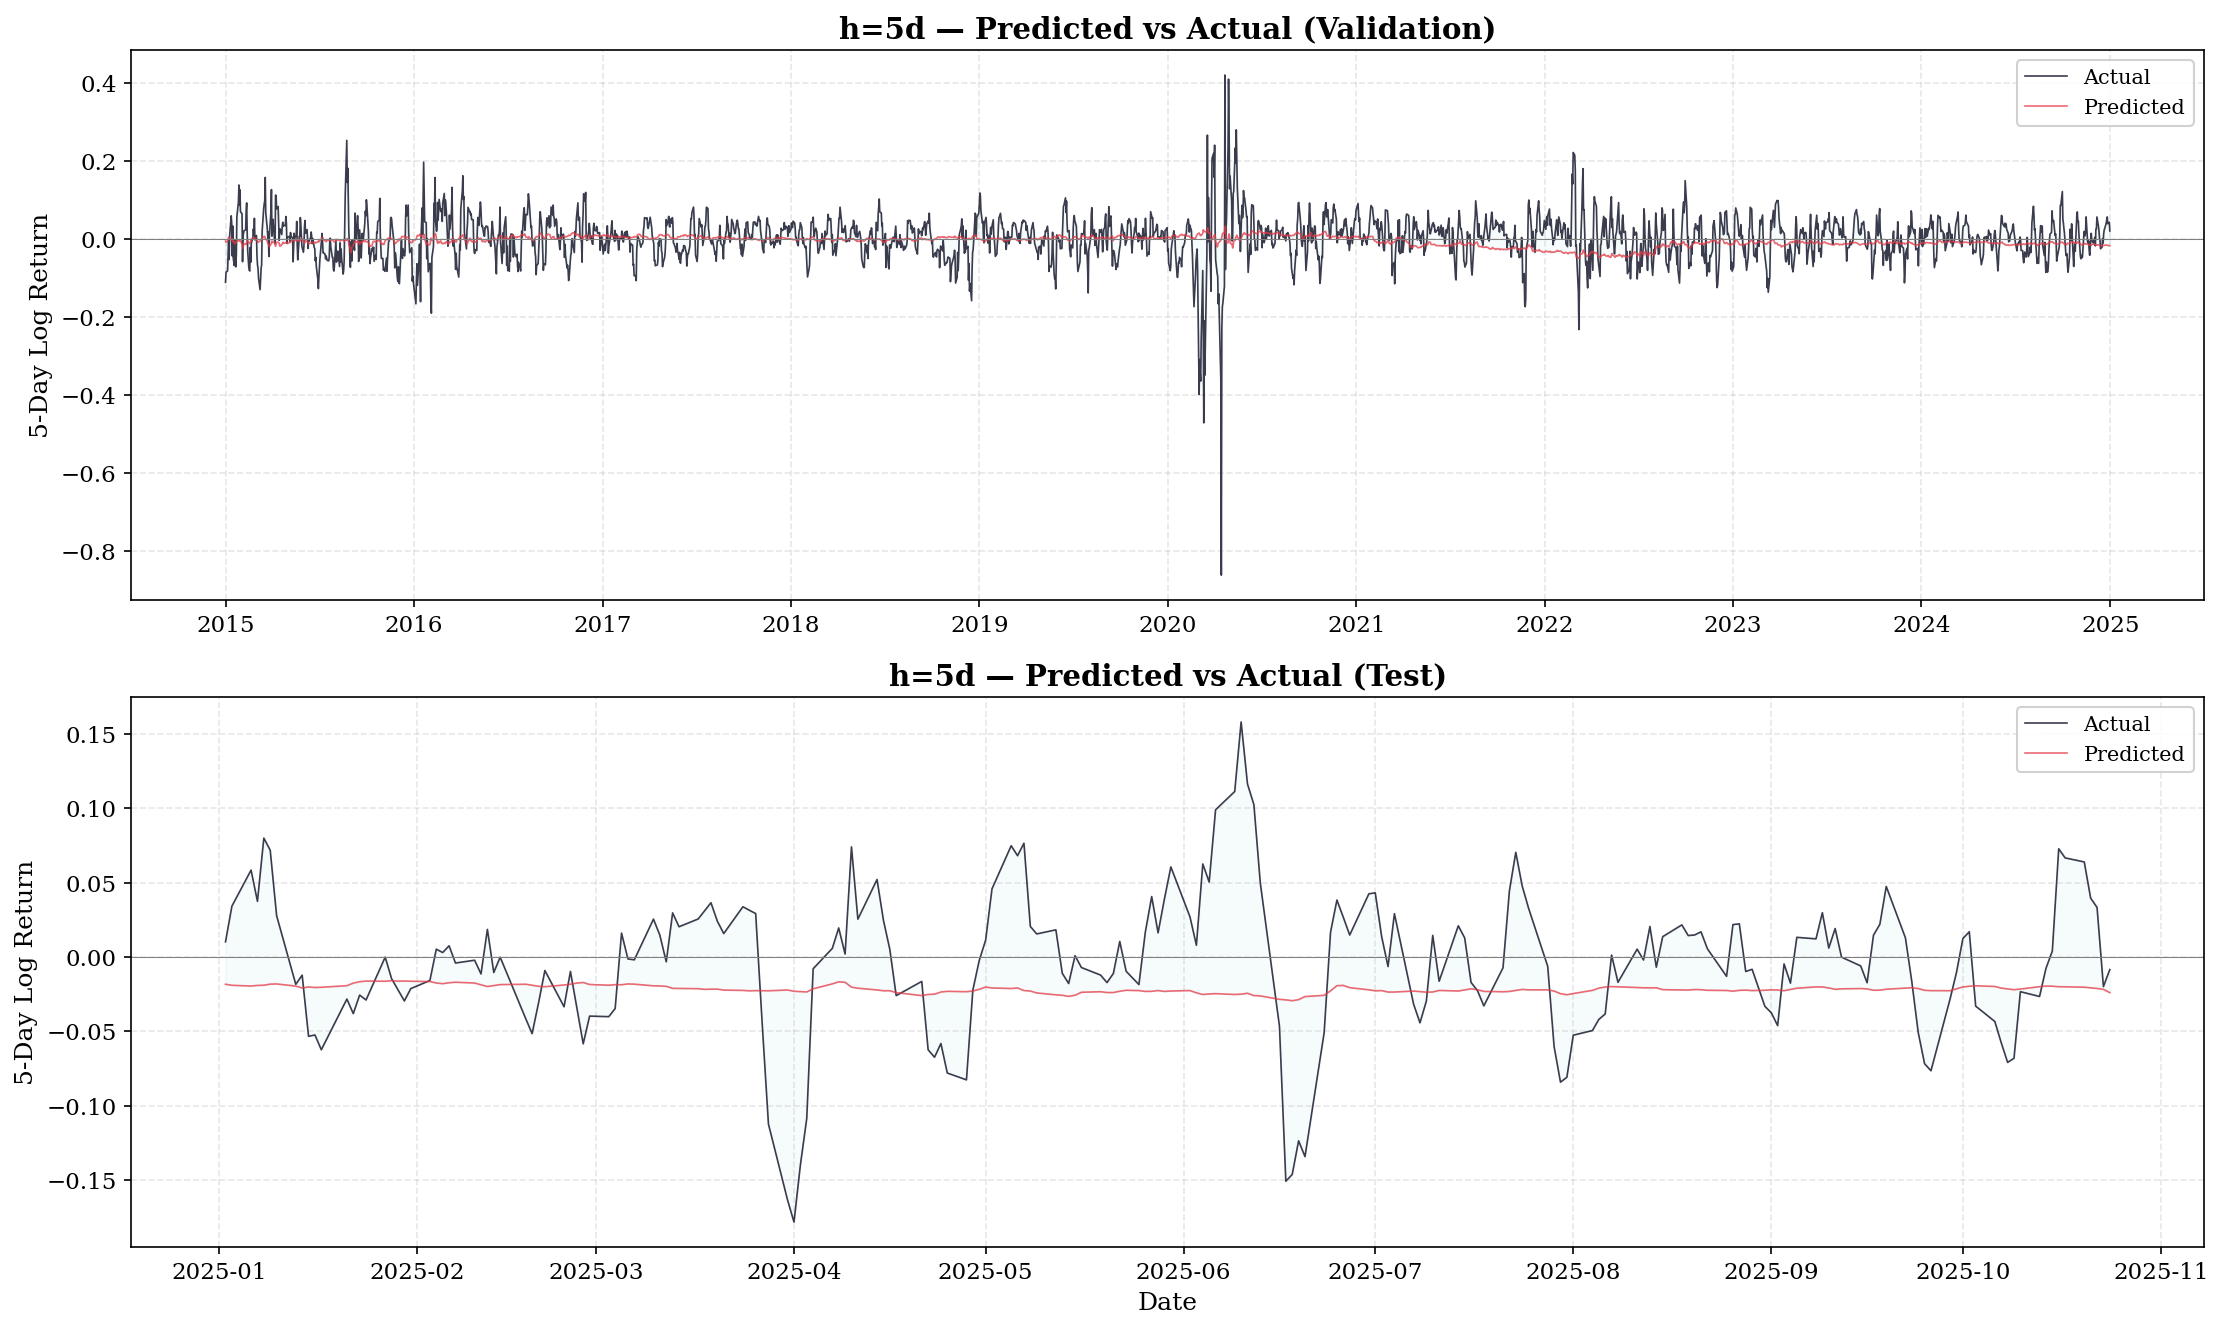

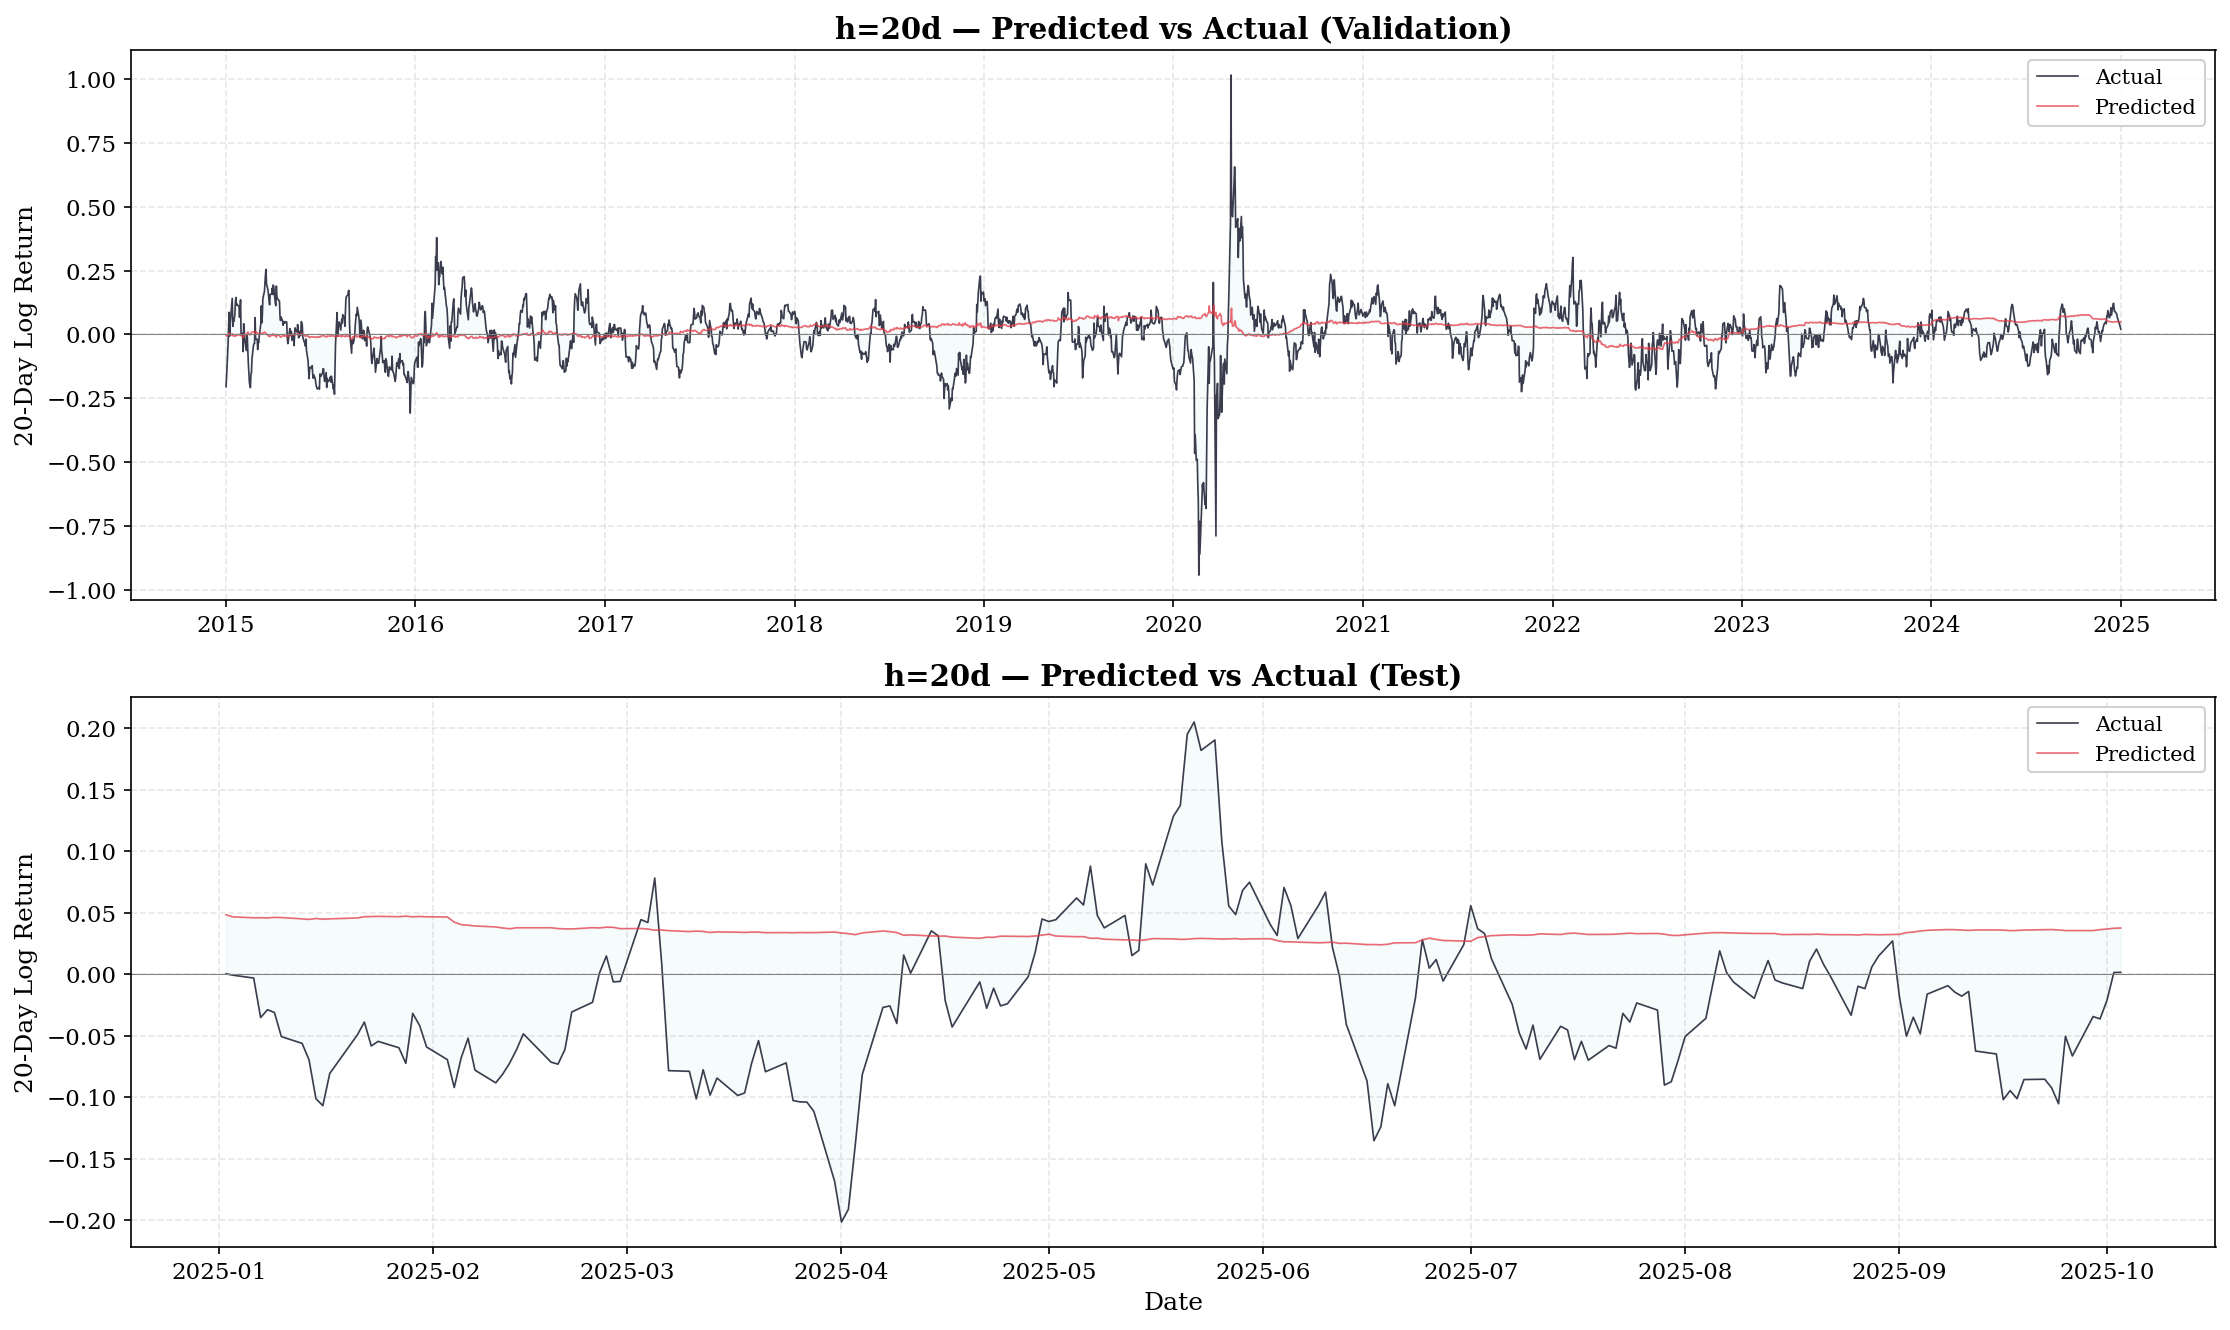

In [6]:
# ============================================================
# CELL 4: Predicted vs Actual — Time Series
# ============================================================

for h in HORIZONS:
    if h not in data: continue
    d = data[h]

    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)

    for ax, dates, y_true, y_pred, label in [
        (axes[0], d['dva'], d['yva'], d['pred_val'], 'Validation'),
        (axes[1], d['dte'], d['yte'], d['pred_test'], 'Test'),
    ]:
        ax.plot(dates, y_true, color=COLORS['actual'], linewidth=0.8, alpha=0.85, label='Actual')
        ax.plot(dates, y_pred, color=COLORS['pred'], linewidth=0.8, alpha=0.75, label='Predicted')
        ax.fill_between(dates, y_true, y_pred, alpha=0.10, color=COLORS['fill'])
        ax.axhline(0, color='gray', linewidth=0.5)
        ax.set_title(f'h={h}d — Predicted vs Actual ({label})', fontweight='bold')
        ax.set_ylabel(f'{h}-Day Log Return')
        ax.legend(loc='upper right', framealpha=0.9)

    axes[1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

Using device: cuda
Retraining h=1d for loss curves...
Retraining h=5d for loss curves...
Retraining h=20d for loss curves...


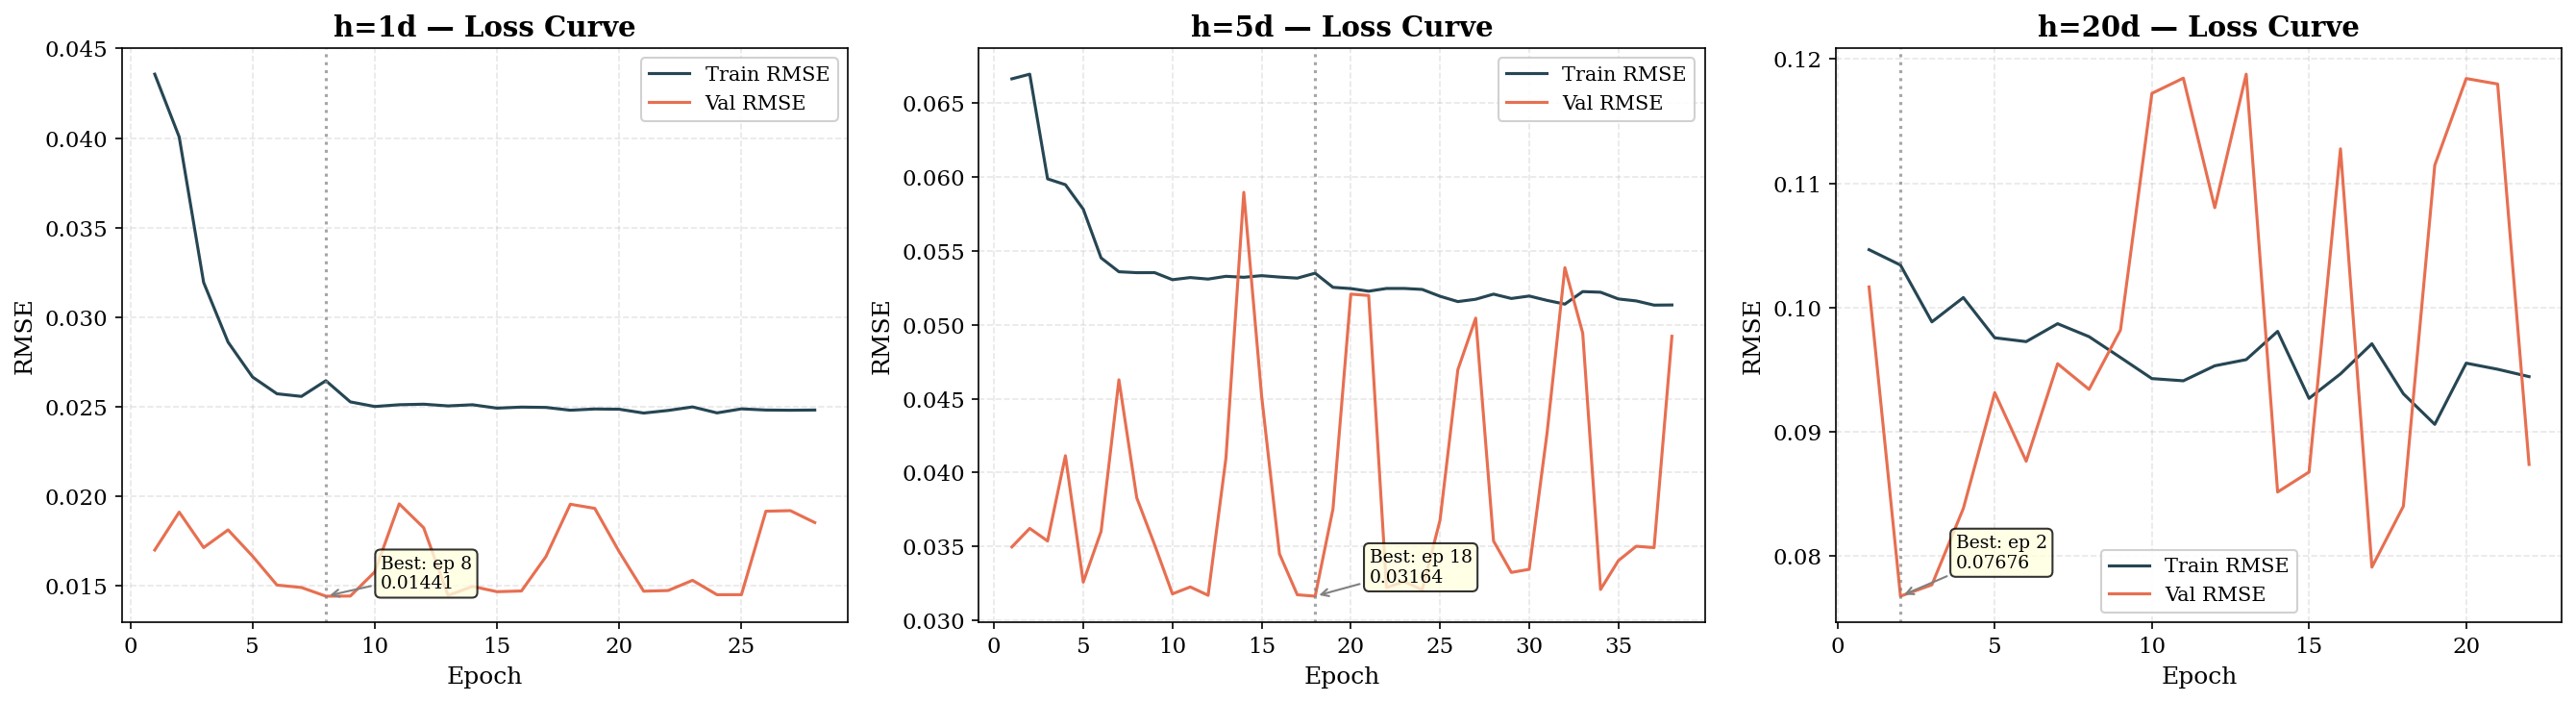

In [7]:
# ============================================================
# CELL 5: Training & Validation Loss Curves
# ============================================================

def retrain_with_loss_tracking(X_train, y_train, best_params,
                               epochs=200, patience=20, batch_size=128,
                               device='cpu'):
    n = len(X_train)
    split = int(n * 0.9)
    Xtr, Xva = X_train[:split], X_train[split:]
    ytr, yva = y_train[:split], y_train[split:]

    # Scale
    _, T, F = Xtr.shape
    scaler = StandardScaler()
    scaler.fit(Xtr.reshape(-1, F))
    Xtr_s = scaler.transform(Xtr.reshape(-1, F)).reshape(len(Xtr), T, F).astype(np.float32)
    Xva_s = scaler.transform(Xva.reshape(-1, F)).reshape(len(Xva), T, F).astype(np.float32)

    model = LSTMNet(F, best_params['hidden_size'],
                    best_params['num_layers'], best_params['dropout']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=1e-5)
    criterion = nn.MSELoss()

    train_ds = TensorDataset(torch.tensor(Xtr_s), torch.tensor(ytr))
    val_ds = TensorDataset(torch.tensor(Xva_s), torch.tensor(yva))
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=batch_size * 2, shuffle=False)

    train_losses, val_losses = [], []
    best_val, wait = np.inf, 0

    for epoch in range(1, epochs + 1):
        model.train()
        ep_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item() * len(xb)
        train_losses.append(np.sqrt(ep_loss / len(train_ds)))

        model.eval()
        vp = []
        with torch.no_grad():
            for xb, _ in val_dl:
                vp.append(model(xb.to(device)).cpu().numpy())
        vp = np.concatenate(vp)
        vl = float(np.sqrt(np.mean((yva - vp)**2)))
        val_losses.append(vl)

        if vl < best_val:
            best_val = vl
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    return train_losses, val_losses

# --- Generate loss curves for each horizon ---
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(6 * len(HORIZONS), 5))
if len(HORIZONS) == 1: axes = [axes]

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

for ax, h in zip(axes, HORIZONS):
    if h not in data: continue
    d = data[h]
    bp = d['state']['best_params_']
    print(f'Retraining h={h}d for loss curves...')
    train_l, val_l = retrain_with_loss_tracking(d['Xtr'], d['ytr'], bp, device=device)

    epochs = range(1, len(train_l) + 1)
    ax.plot(epochs, train_l, color=COLORS['h1'], linewidth=1.5, label='Train RMSE')
    ax.plot(epochs, val_l, color=COLORS['neg'], linewidth=1.5, label='Val RMSE')

    best_ep = np.argmin(val_l) + 1
    best_v = min(val_l)
    ax.axvline(best_ep, color='gray', linestyle=':', alpha=0.7)
    ax.annotate(f'Best: ep {best_ep}\n{best_v:.5f}',
                xy=(best_ep, best_v), fontsize=9,
                xytext=(best_ep + len(train_l)*0.08, best_v * 1.03),
                arrowprops=dict(arrowstyle='->', color='gray'),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    ax.set_title(f'h={h}d — Loss Curve', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('RMSE')
    ax.legend(framealpha=0.9)

plt.tight_layout()
plt.show()

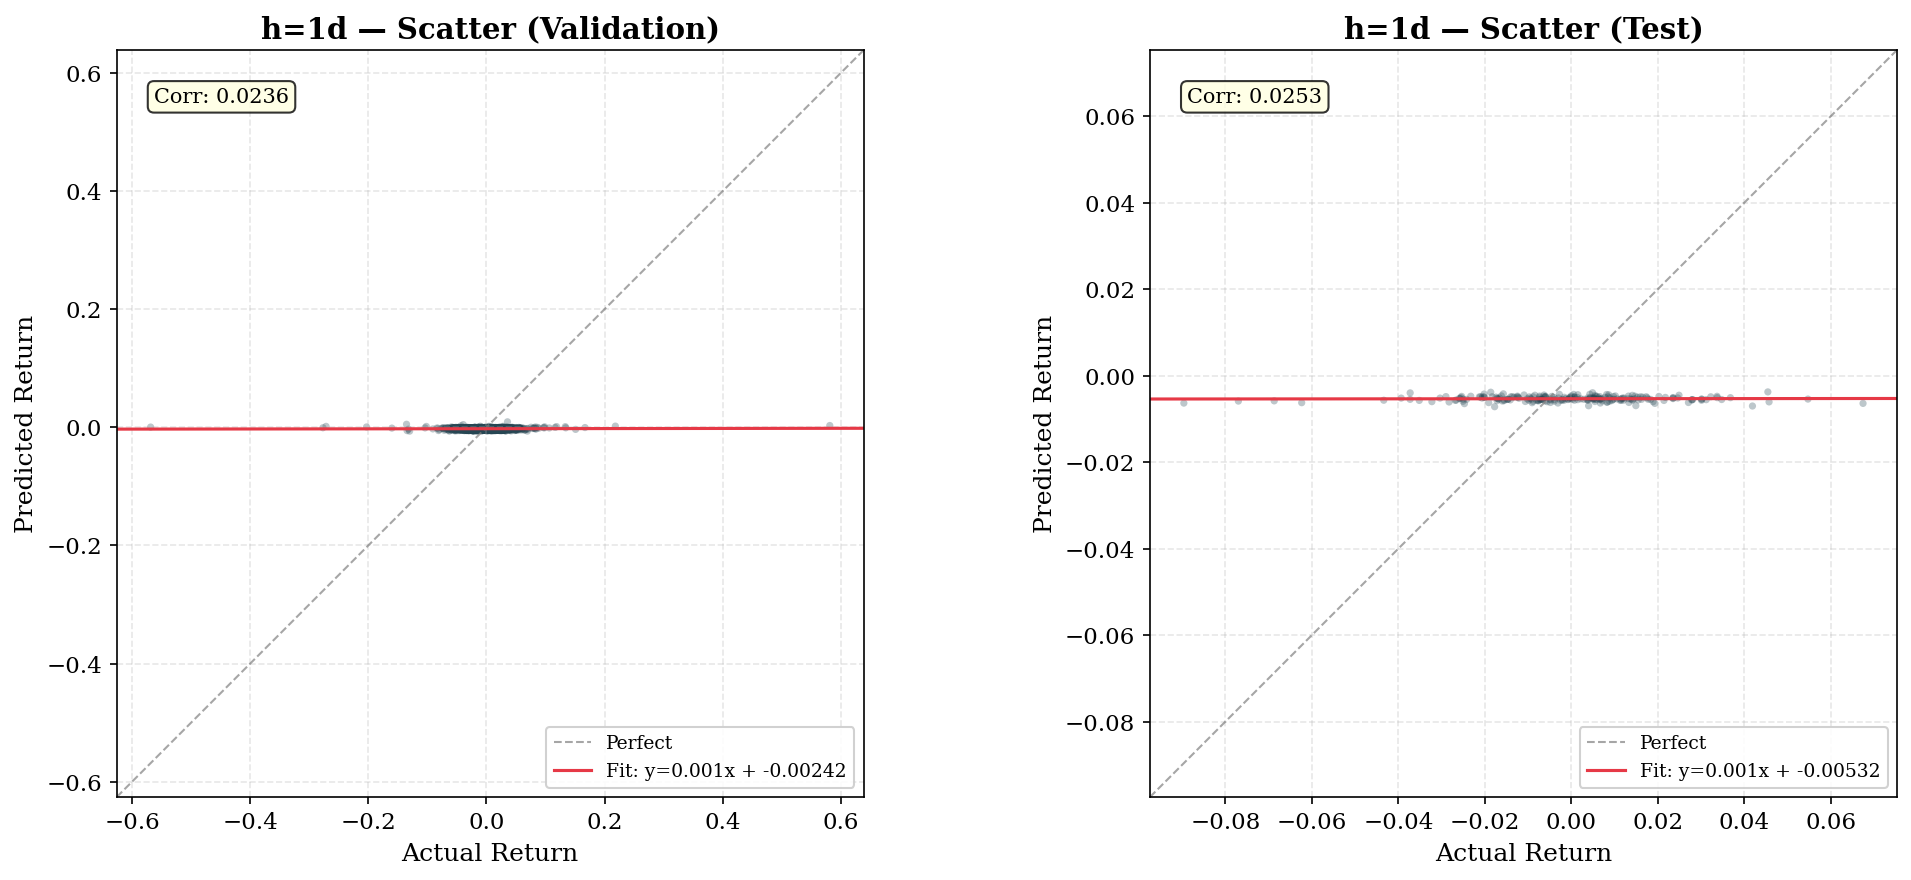

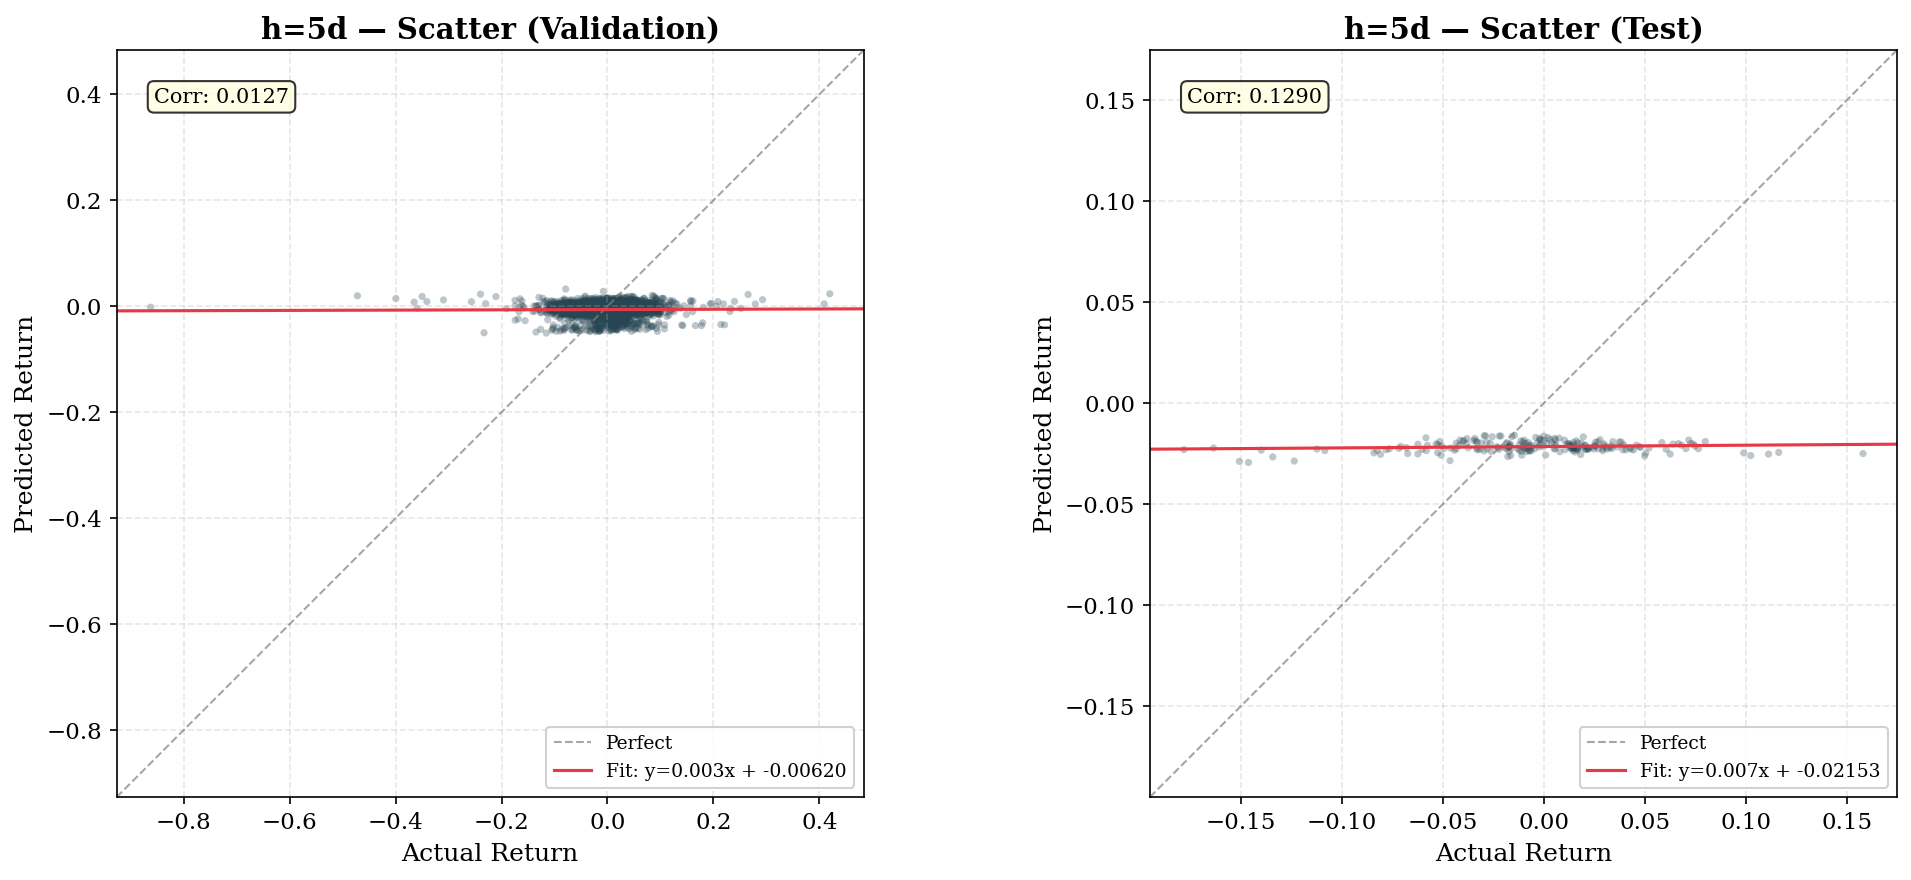

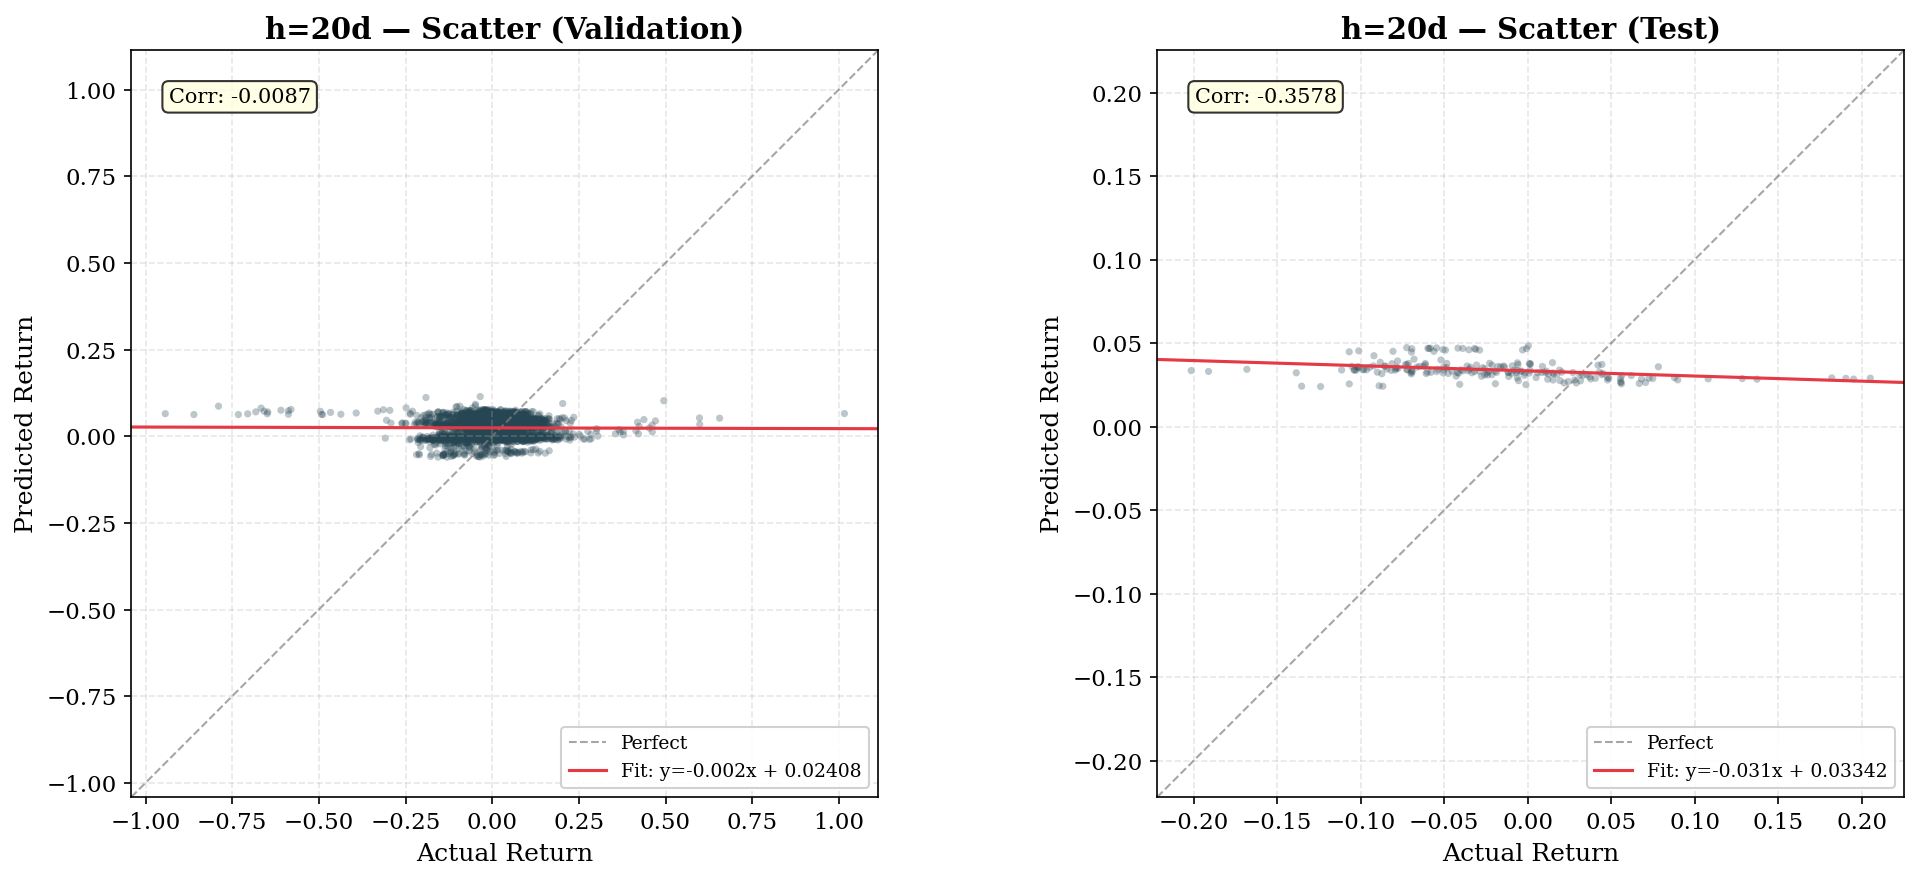

In [8]:
# ============================================================
# CELL 6: Scatter — Predicted vs Actual
# ============================================================

for h in HORIZONS:
    if h not in data: continue
    d = data[h]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, y_true, y_pred, label in [
        (axes[0], d['yva'], d['pred_val'], 'Validation'),
        (axes[1], d['yte'], d['pred_test'], 'Test'),
    ]:
        ax.scatter(y_true, y_pred, alpha=0.3, s=12, color=COLORS['h1'], edgecolors='none')

        # Limits
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        margin = (lims[1] - lims[0]) * 0.05
        lims = [lims[0] - margin, lims[1] + margin]

        # 45-degree line
        ax.plot(lims, lims, '--', color='gray', linewidth=1, alpha=0.7, label='Perfect')

        # Regression line
        z = np.polyfit(y_true, y_pred, 1)
        x_line = np.linspace(lims[0], lims[1], 100)
        ax.plot(x_line, np.poly1d(z)(x_line), color=COLORS['pred'], linewidth=1.5,
                label=f'Fit: y={z[0]:.3f}x + {z[1]:.5f}')

        corr = np.corrcoef(y_true, y_pred)[0, 1]
        ax.text(0.05, 0.95, f'Corr: {corr:.4f}', transform=ax.transAxes,
                fontsize=10, va='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect('equal')
        ax.set_title(f'h={h}d — Scatter ({label})', fontweight='bold')
        ax.set_xlabel('Actual Return')
        ax.set_ylabel('Predicted Return')
        ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()

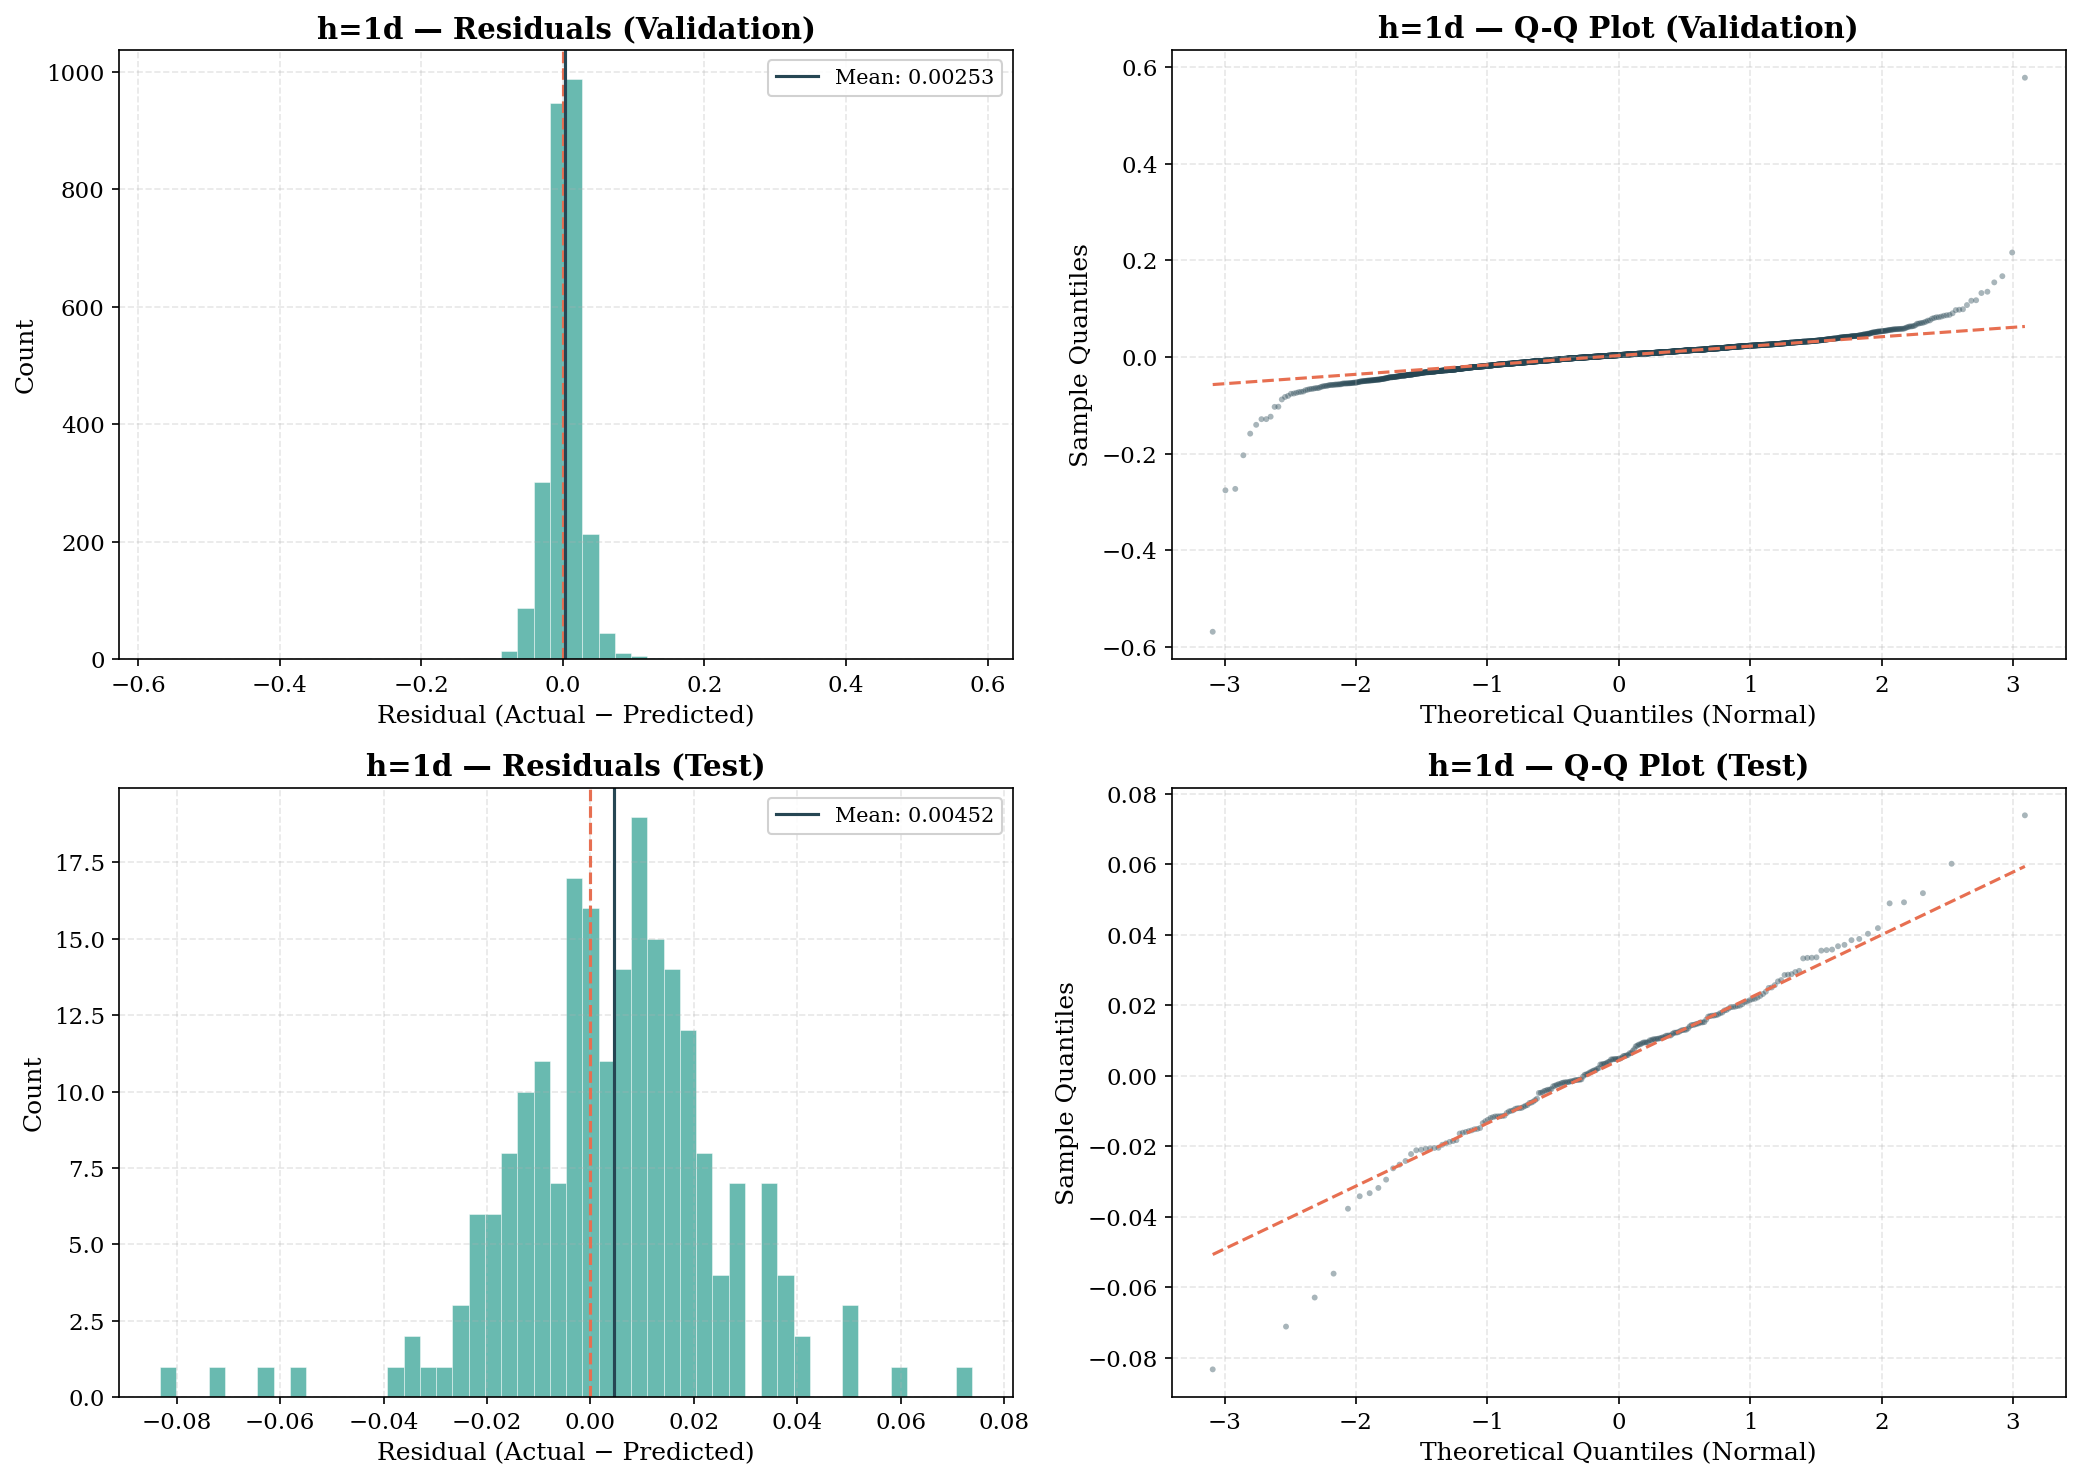

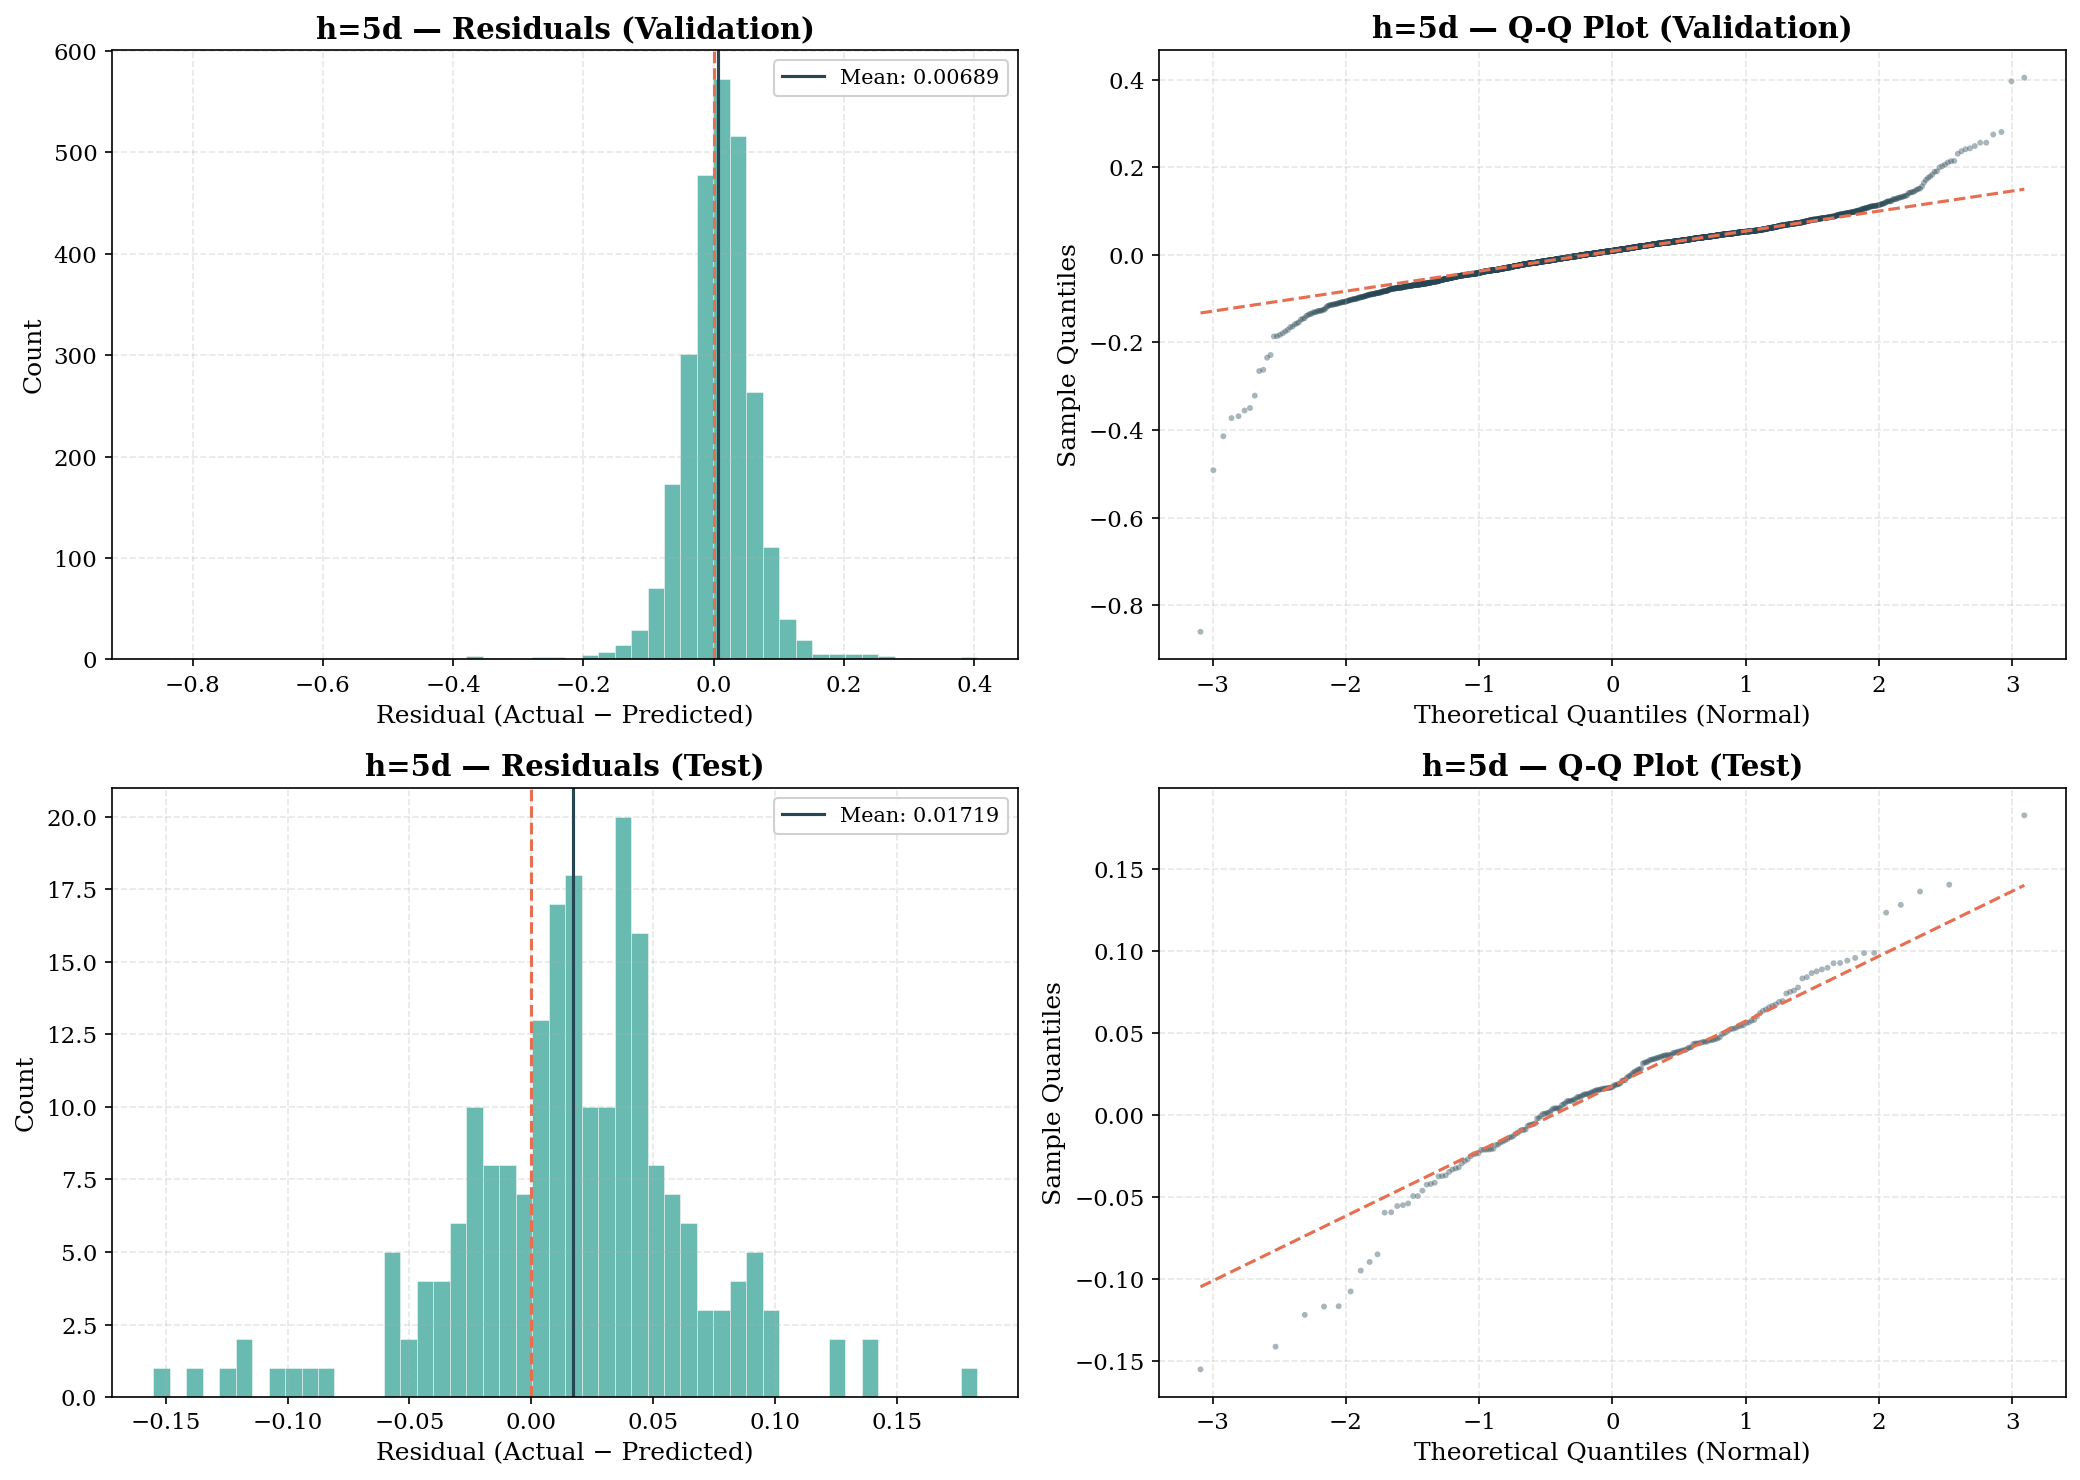

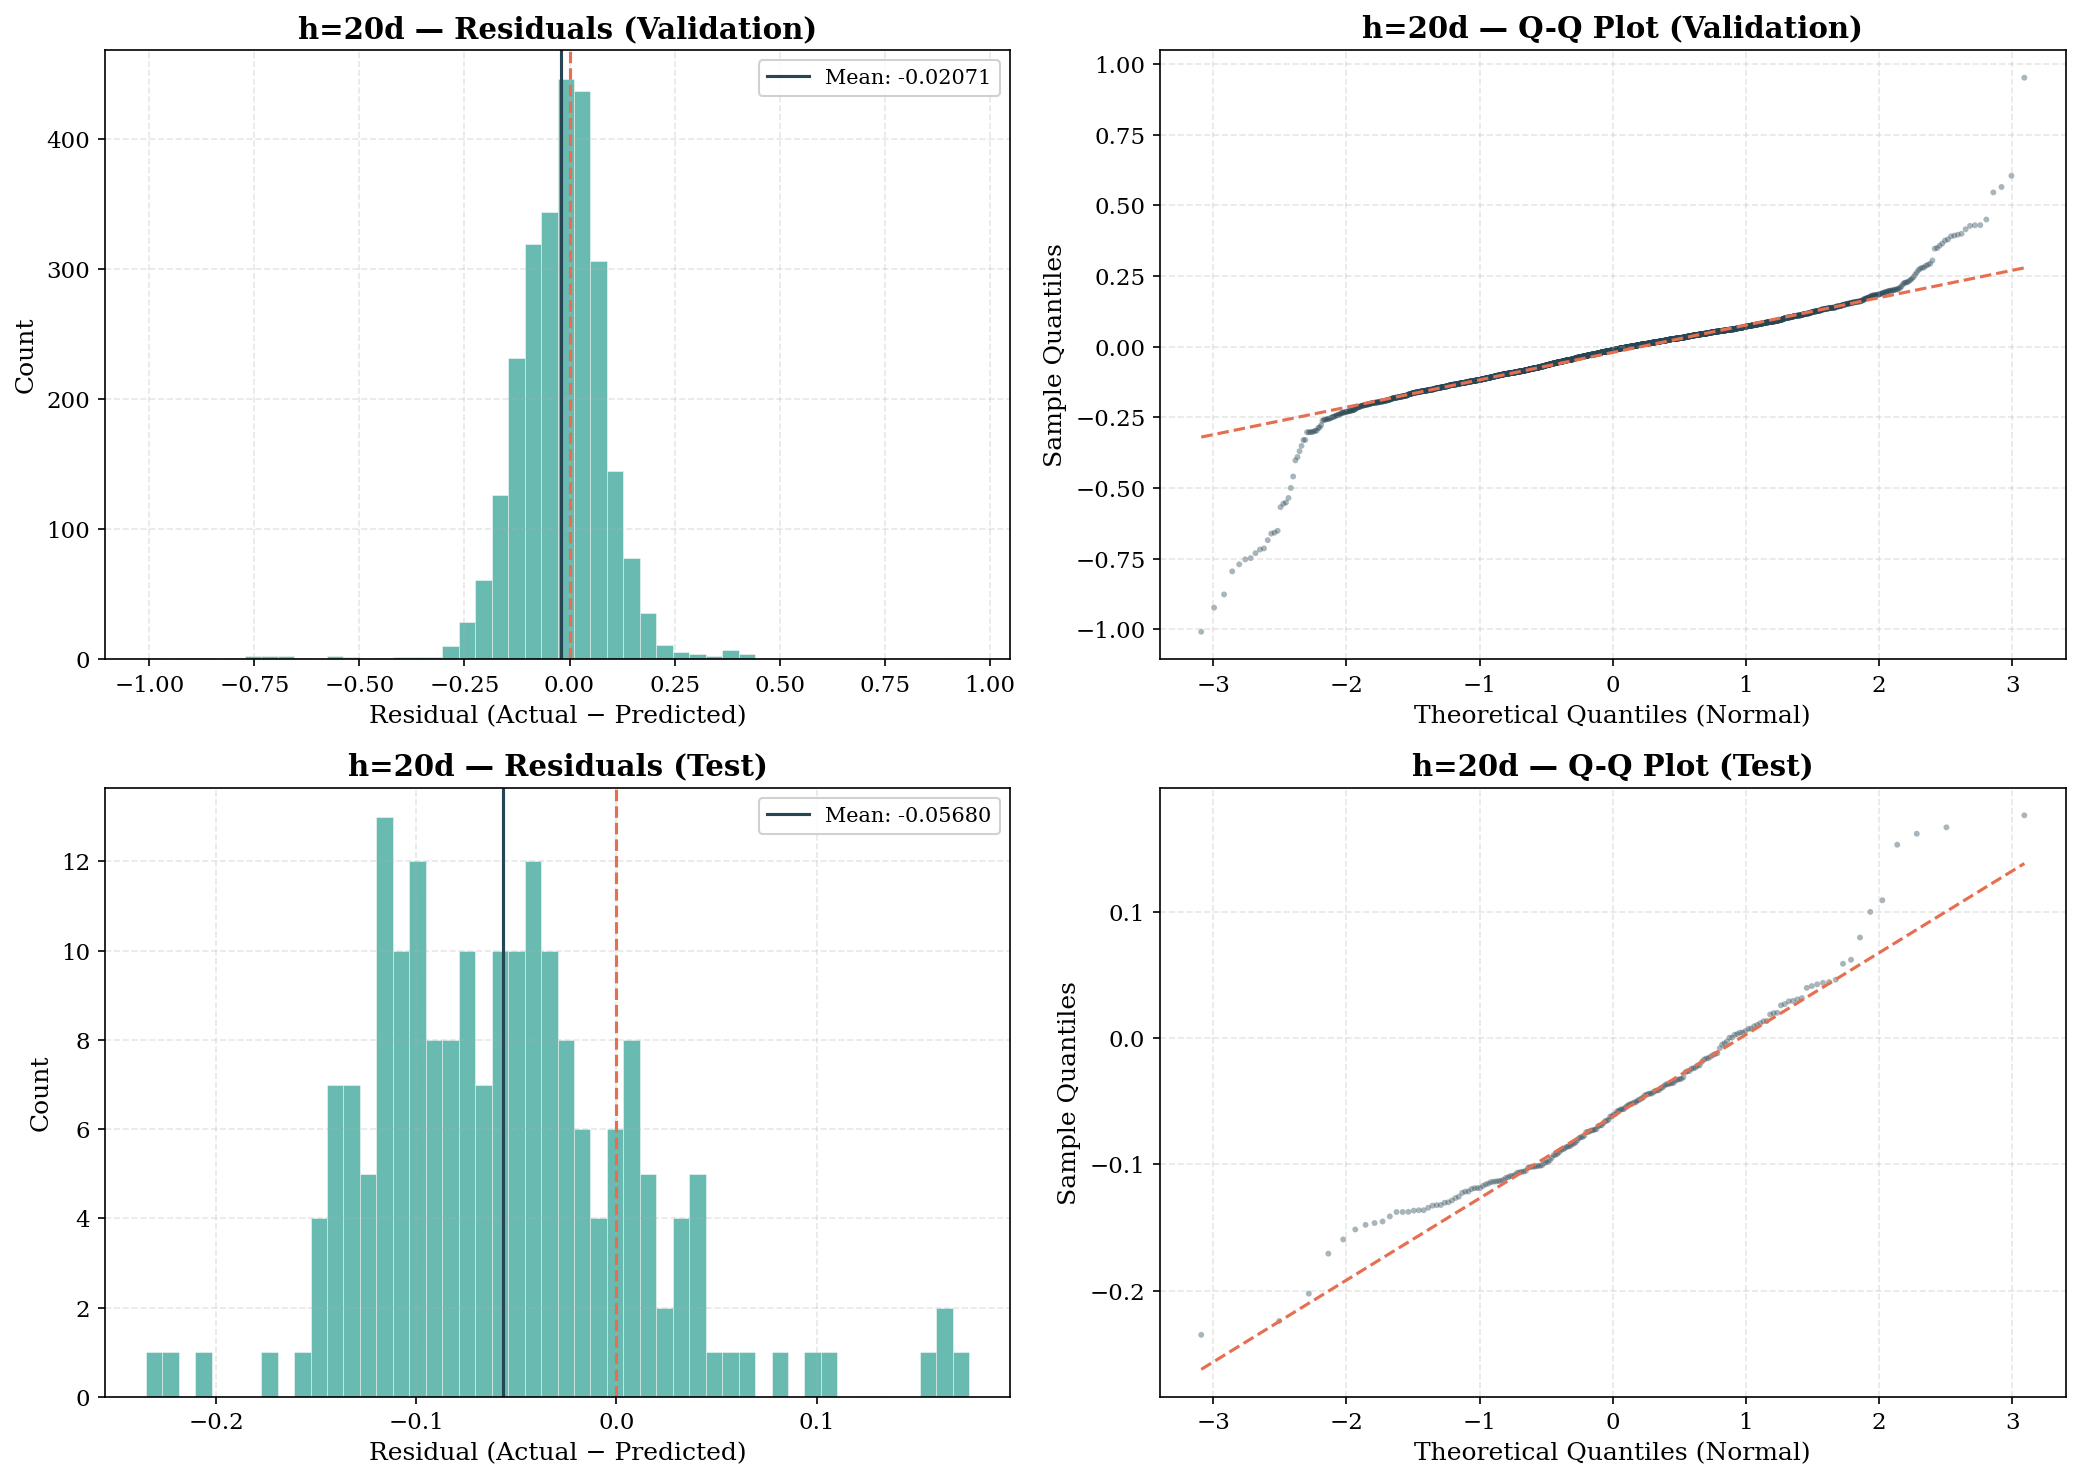

In [9]:
# ============================================================
# CELL 7: Residual Analysis — Histogram + Q-Q Plot
# ============================================================

for h in HORIZONS:
    if h not in data: continue
    d = data[h]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for row, (y_true, y_pred, label) in enumerate([
        (d['yva'], d['pred_val'], 'Validation'),
        (d['yte'], d['pred_test'], 'Test'),
    ]):
        residuals = y_true - y_pred

        # Histogram
        ax = axes[row, 0]
        ax.hist(residuals, bins=50, color=COLORS['h5'], alpha=0.7,
                edgecolor='white', linewidth=0.3)
        ax.axvline(0, color=COLORS['neg'], linewidth=1.5, linestyle='--')
        ax.axvline(residuals.mean(), color=COLORS['h1'], linewidth=1.5,
                   label=f'Mean: {residuals.mean():.5f}')
        ax.set_title(f'h={h}d — Residuals ({label})', fontweight='bold')
        ax.set_xlabel('Residual (Actual − Predicted)')
        ax.set_ylabel('Count')
        ax.legend(framealpha=0.9)

        # Q-Q Plot
        ax2 = axes[row, 1]
        sorted_res = np.sort(residuals)
        n = len(sorted_res)
        theoretical = stats.norm.ppf(np.linspace(0.001, 0.999, n))
        ax2.scatter(theoretical, sorted_res, alpha=0.4, s=8,
                    color=COLORS['h1'], edgecolors='none')
        q25, q75 = np.percentile(sorted_res, [25, 75])
        t25, t75 = stats.norm.ppf(0.25), stats.norm.ppf(0.75)
        slope = (q75 - q25) / (t75 - t25)
        intercept = q25 - slope * t25
        ref_x = np.array([theoretical.min(), theoretical.max()])
        ax2.plot(ref_x, slope * ref_x + intercept, '--',
                 color=COLORS['neg'], linewidth=1.5)
        ax2.set_title(f'h={h}d — Q-Q Plot ({label})', fontweight='bold')
        ax2.set_xlabel('Theoretical Quantiles (Normal)')
        ax2.set_ylabel('Sample Quantiles')

    plt.tight_layout()
    plt.show()

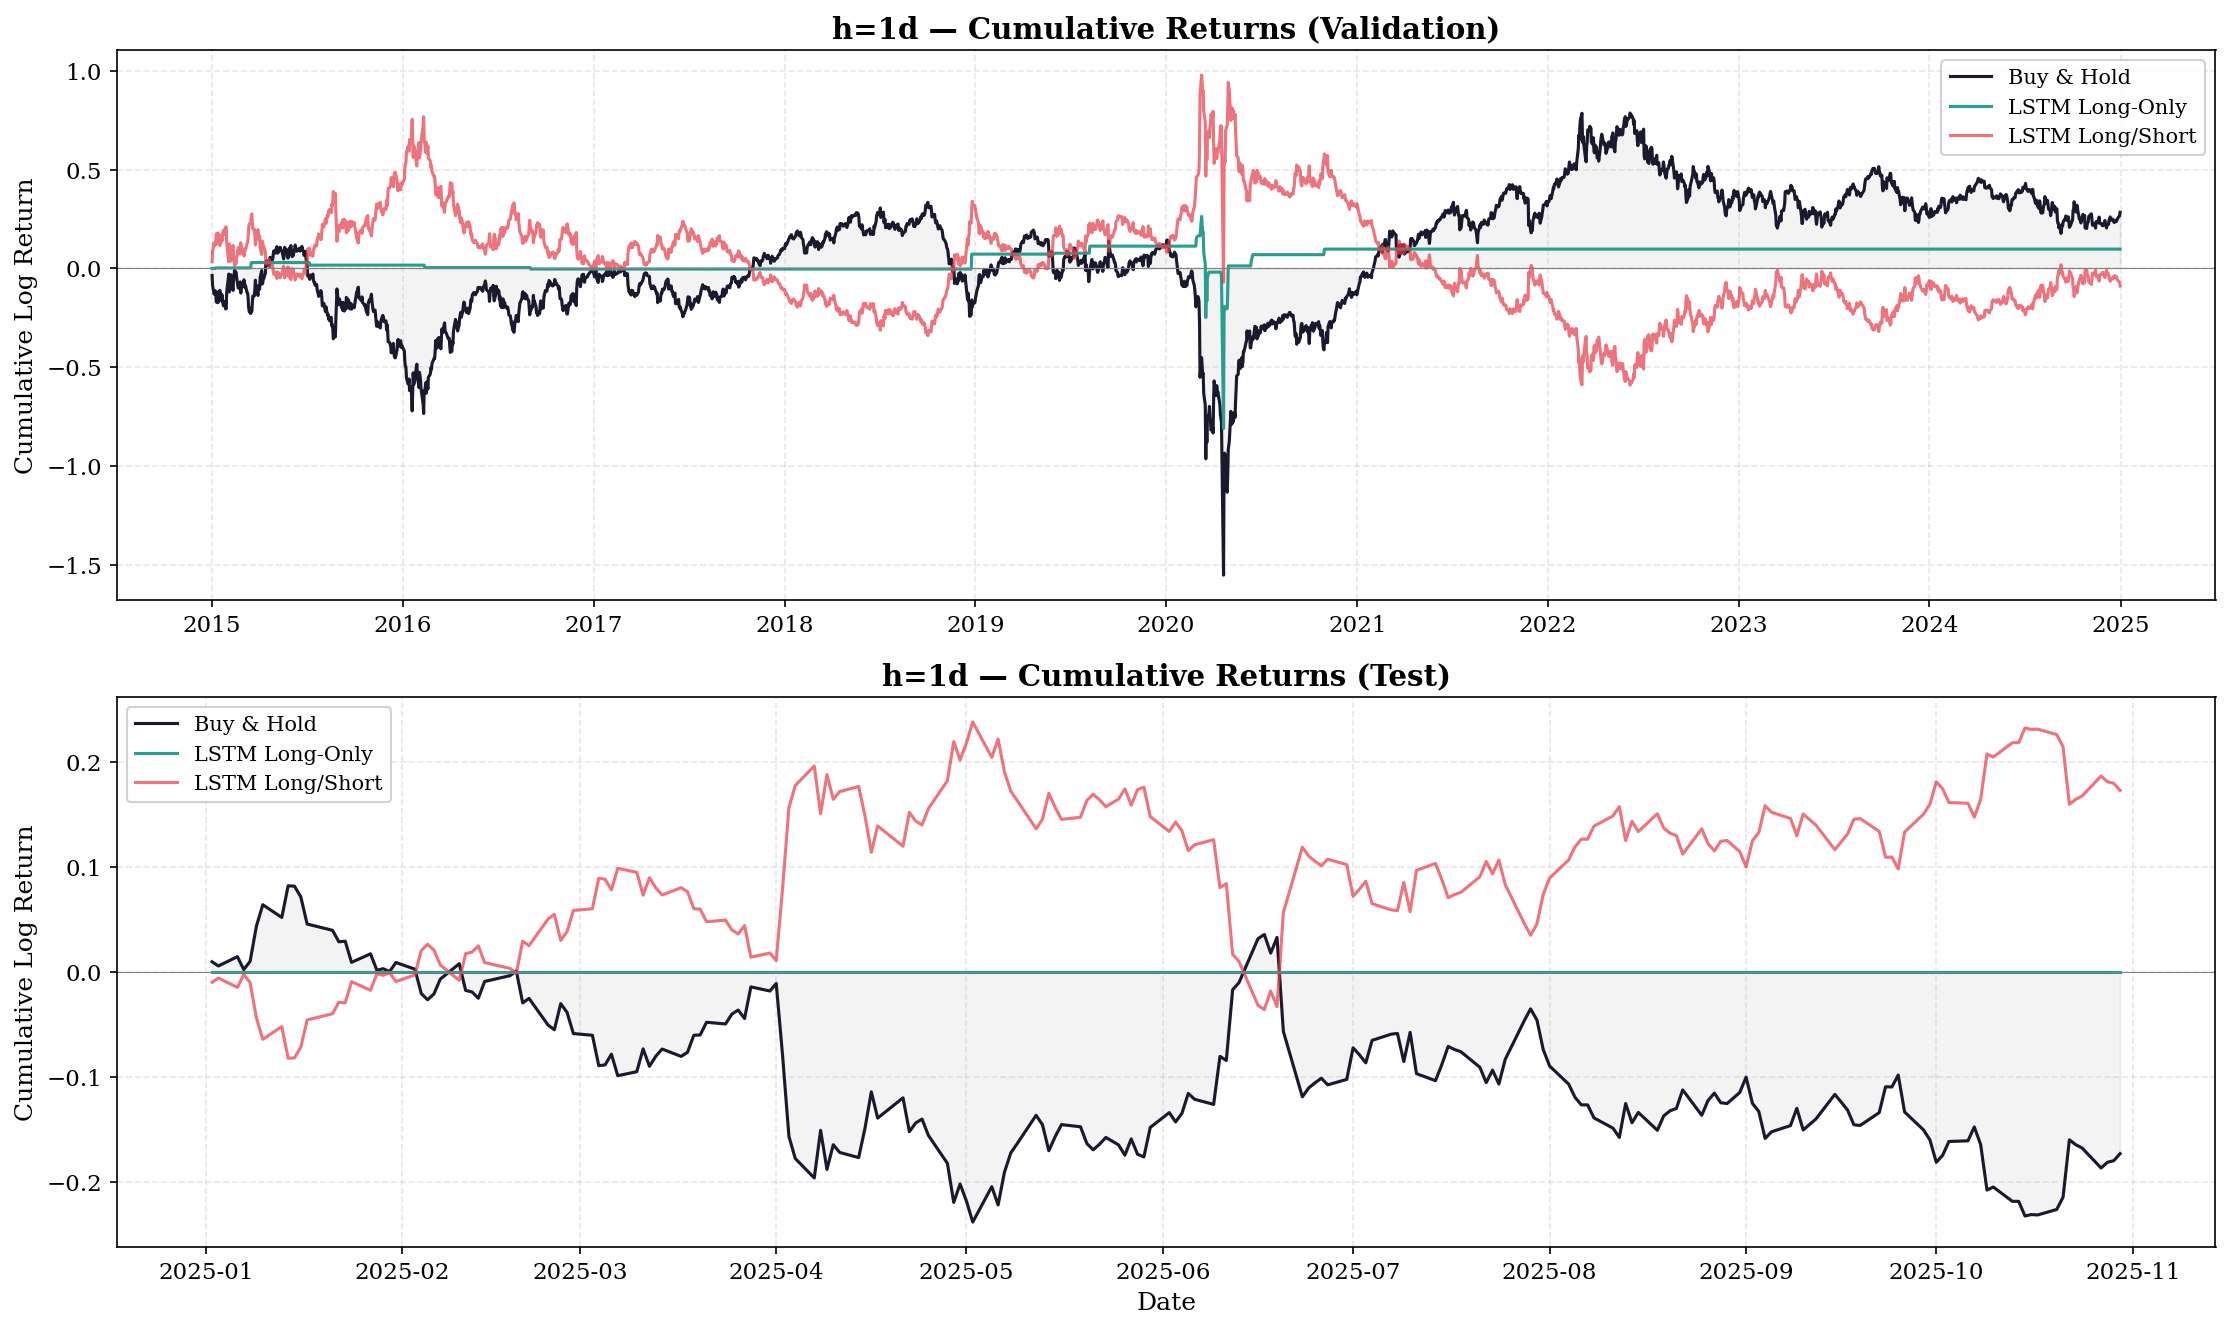

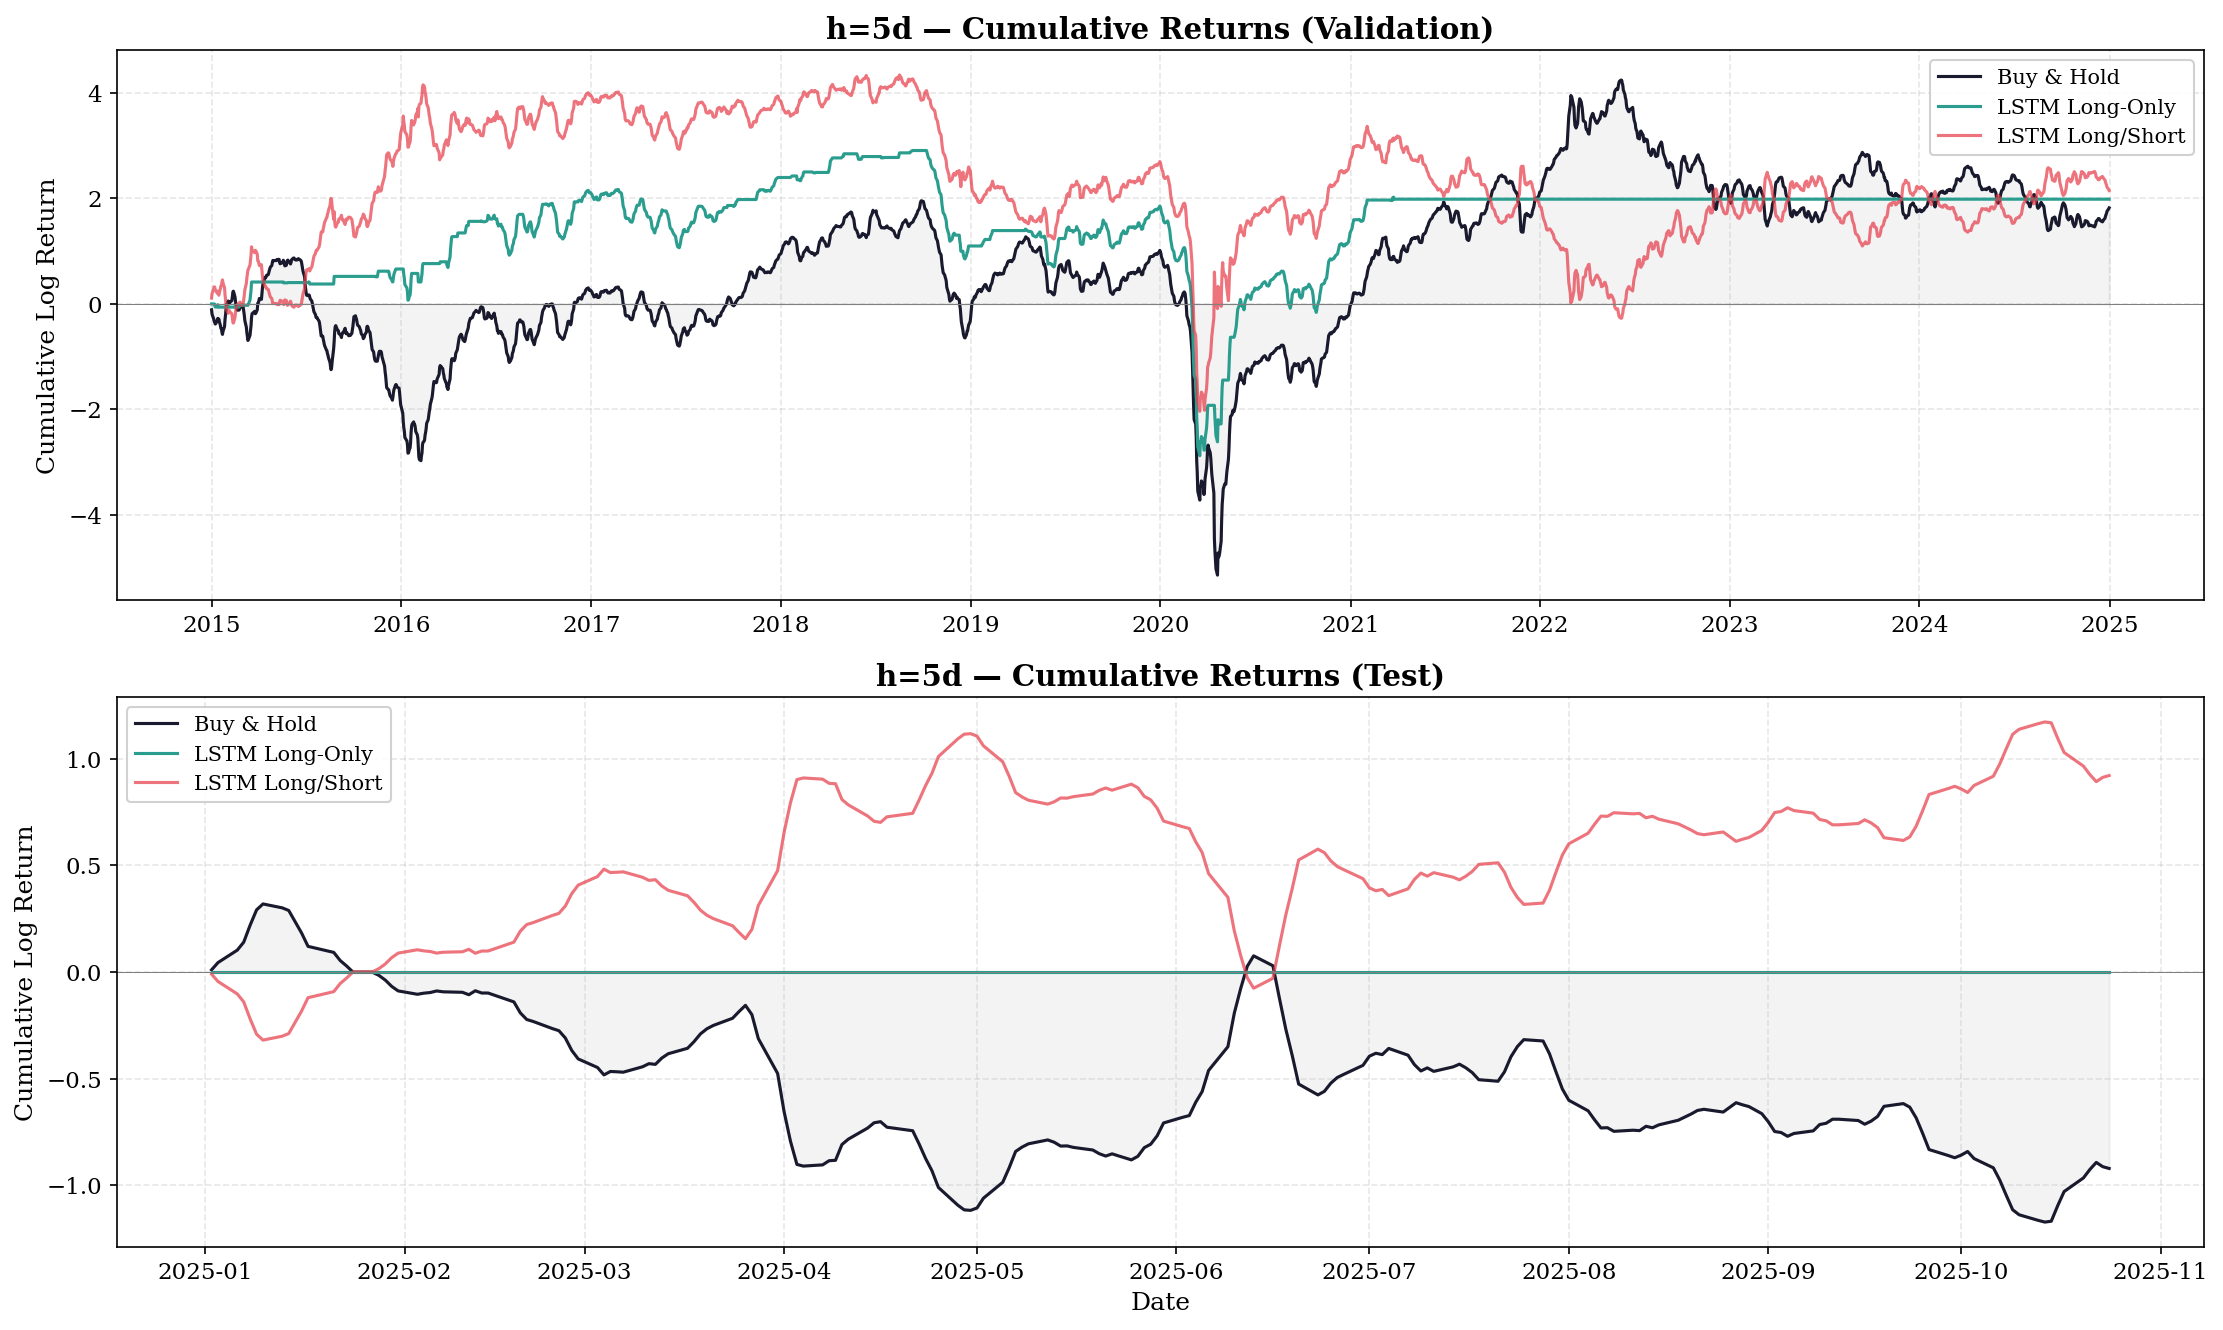

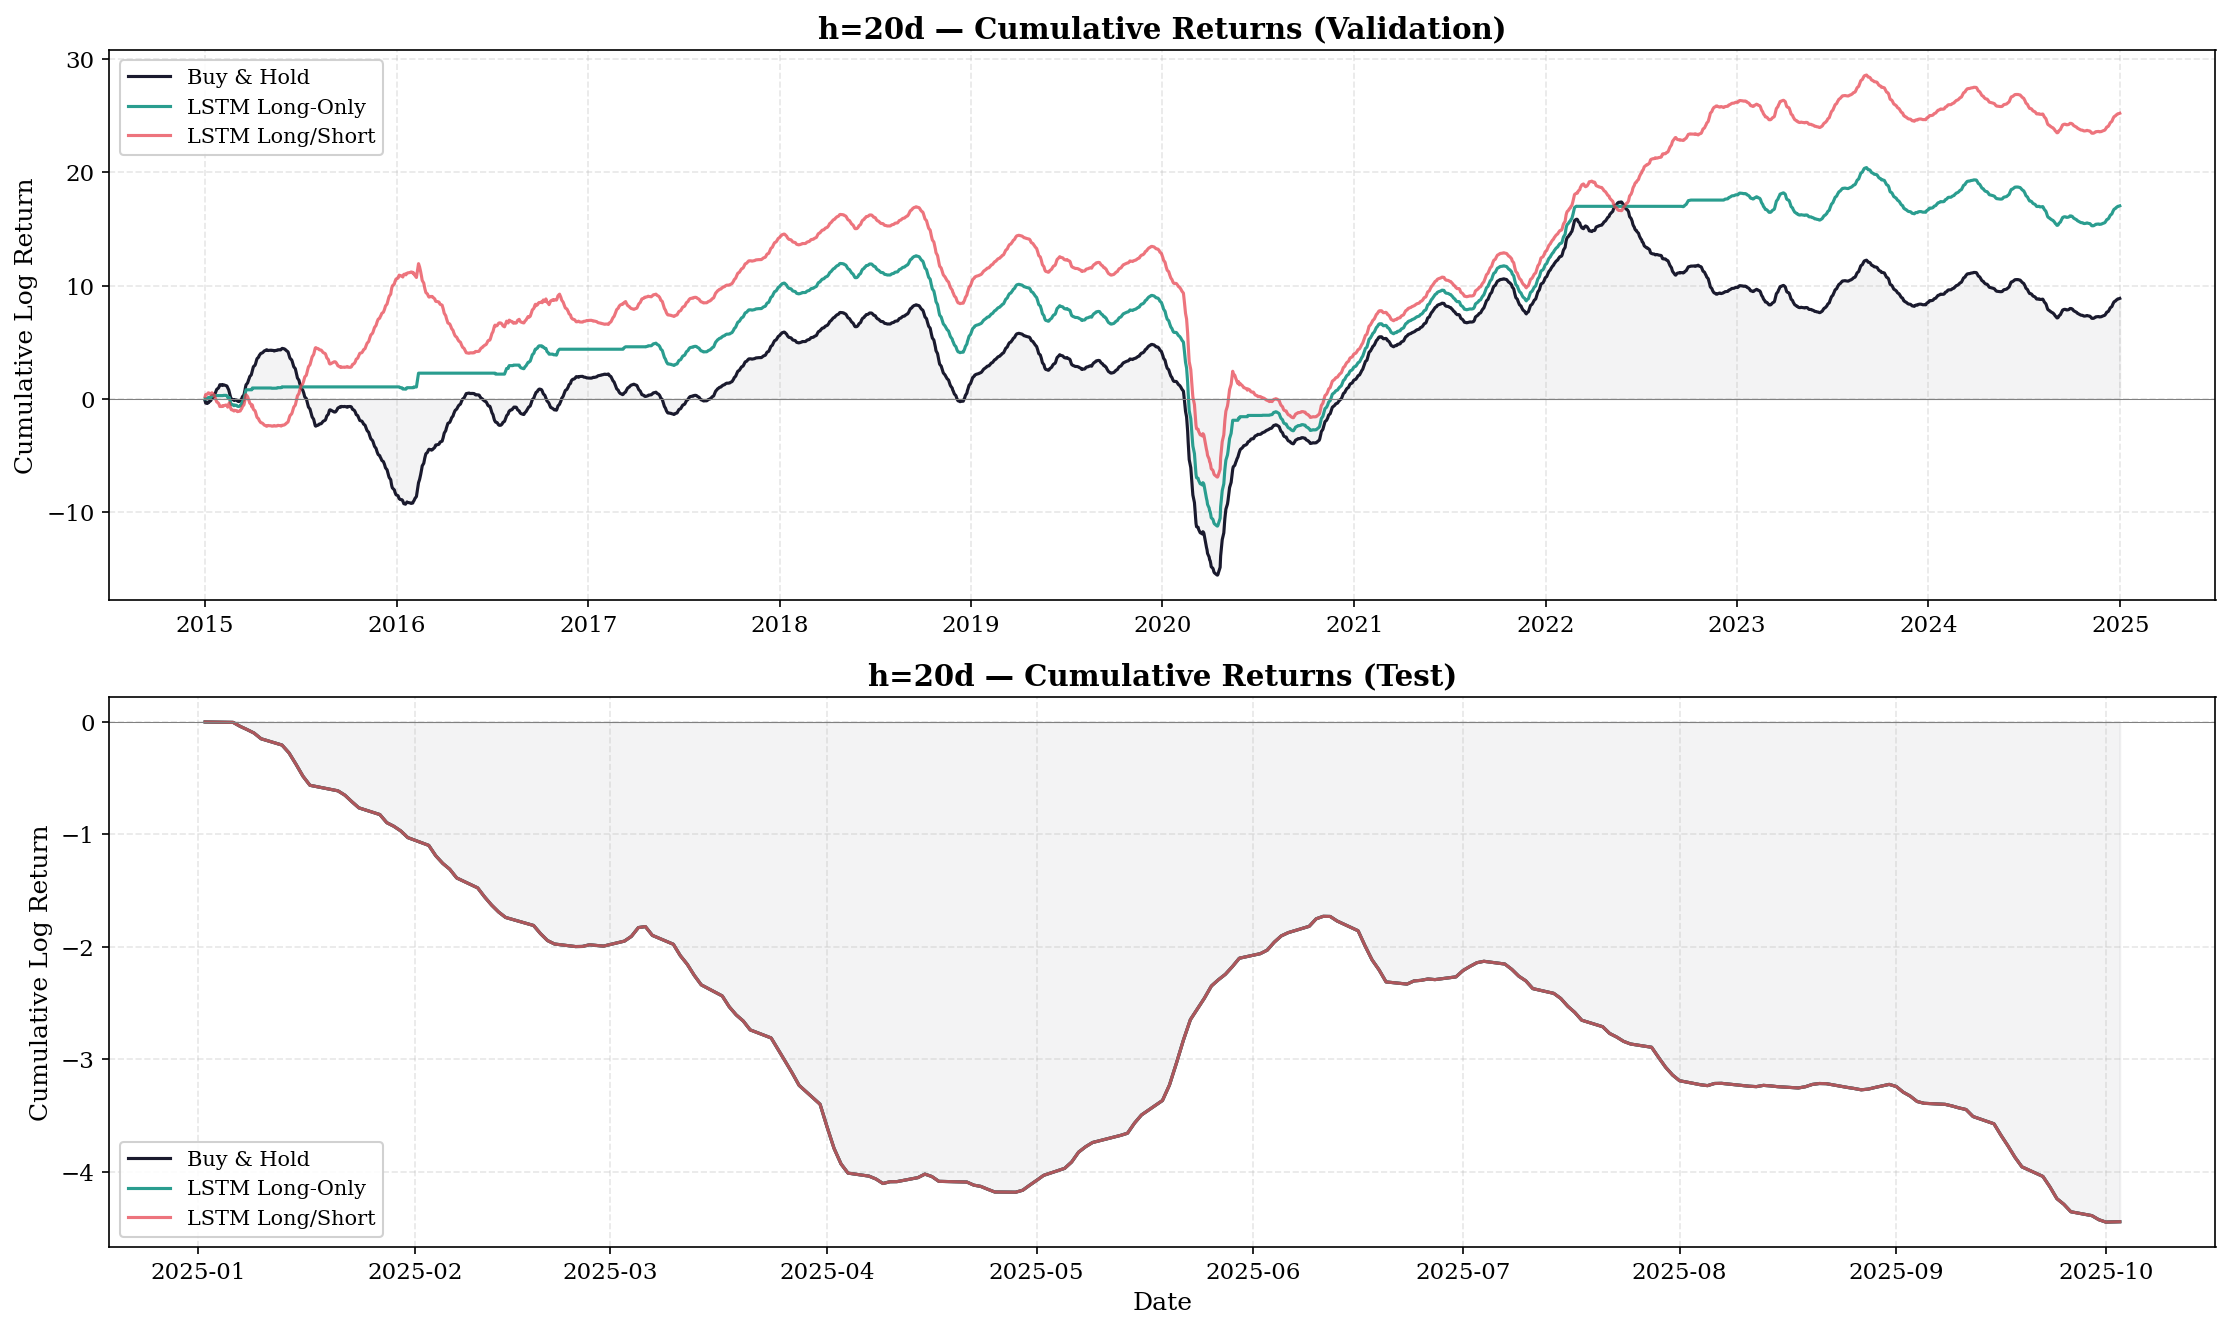

In [10]:
# ============================================================
# CELL 8: Cumulative Returns — Buy & Hold vs LSTM Strategy
# ============================================================

for h in HORIZONS:
    if h not in data: continue
    d = data[h]

    fig, axes = plt.subplots(2, 1, figsize=(15, 9))

    for ax, dates, y_true, y_pred, label in [
        (axes[0], d['dva'], d['yva'], d['pred_val'], 'Validation'),
        (axes[1], d['dte'], d['yte'], d['pred_test'], 'Test'),
    ]:
        cum_actual = np.cumsum(y_true)
        cum_long = np.cumsum(np.where(y_pred > 0, y_true, 0))
        cum_ls = np.cumsum(np.where(y_pred > 0, y_true, -y_true))

        ax.plot(dates, cum_actual, color=COLORS['actual'], linewidth=1.5,
                label='Buy & Hold')
        ax.plot(dates, cum_long, color=COLORS['pos'], linewidth=1.5,
                label='LSTM Long-Only')
        ax.plot(dates, cum_ls, color=COLORS['pred'], linewidth=1.5, alpha=0.7,
                label='LSTM Long/Short')
        ax.axhline(0, color='gray', linewidth=0.5)
        ax.fill_between(dates, cum_actual, alpha=0.05, color=COLORS['actual'])

        ax.set_title(f'h={h}d — Cumulative Returns ({label})', fontweight='bold')
        ax.set_ylabel('Cumulative Log Return')
        ax.legend(loc='best', framealpha=0.9)

    axes[1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

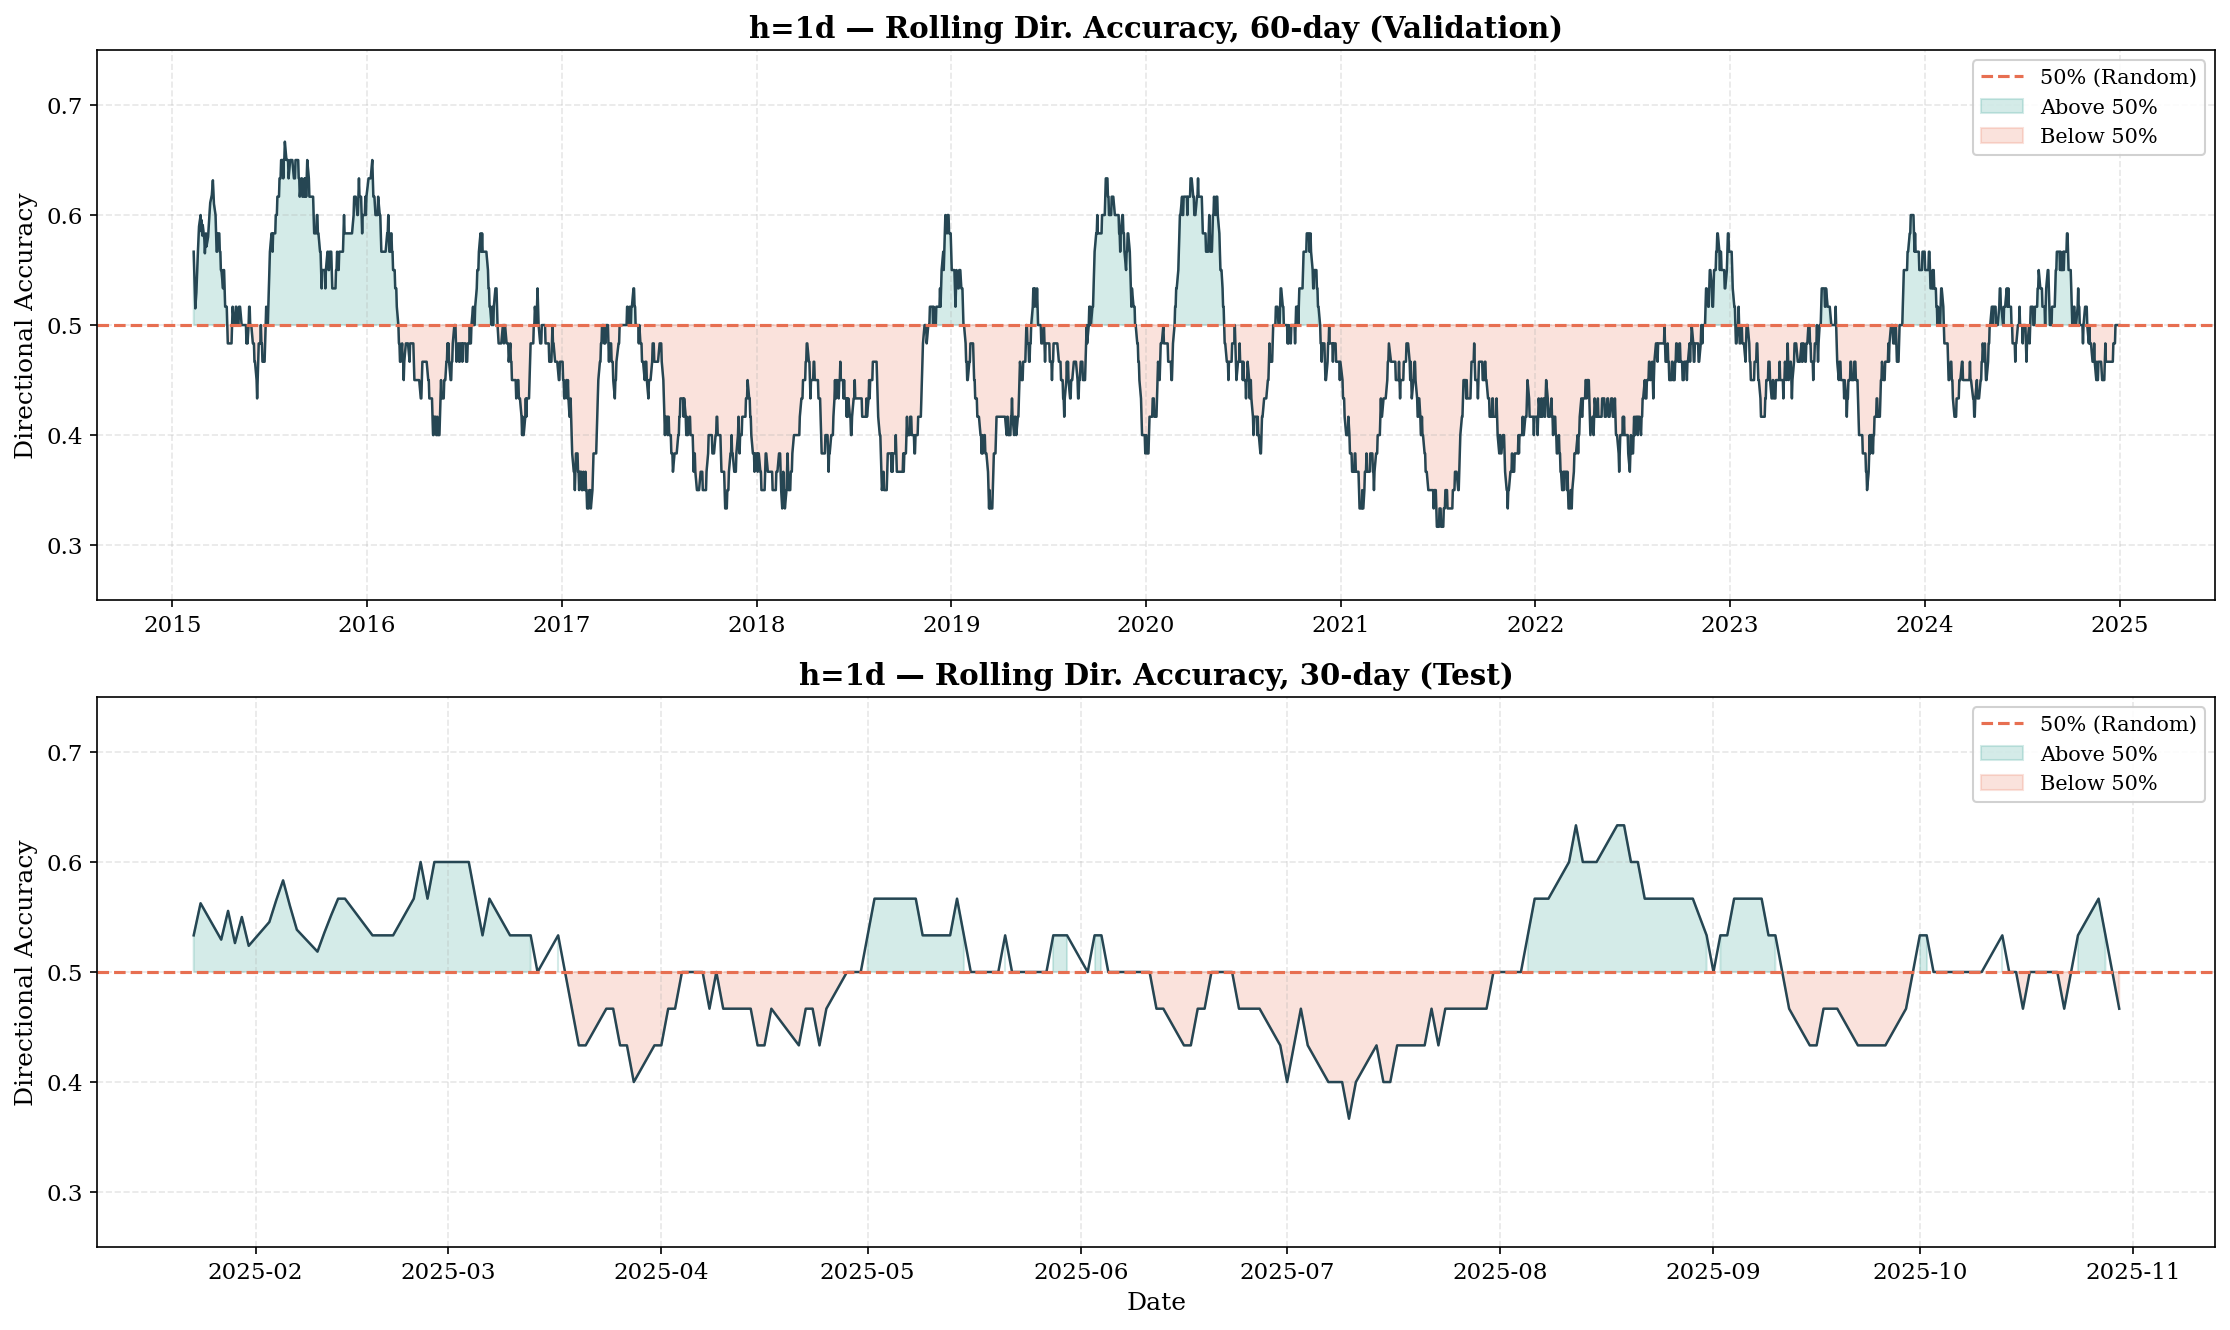

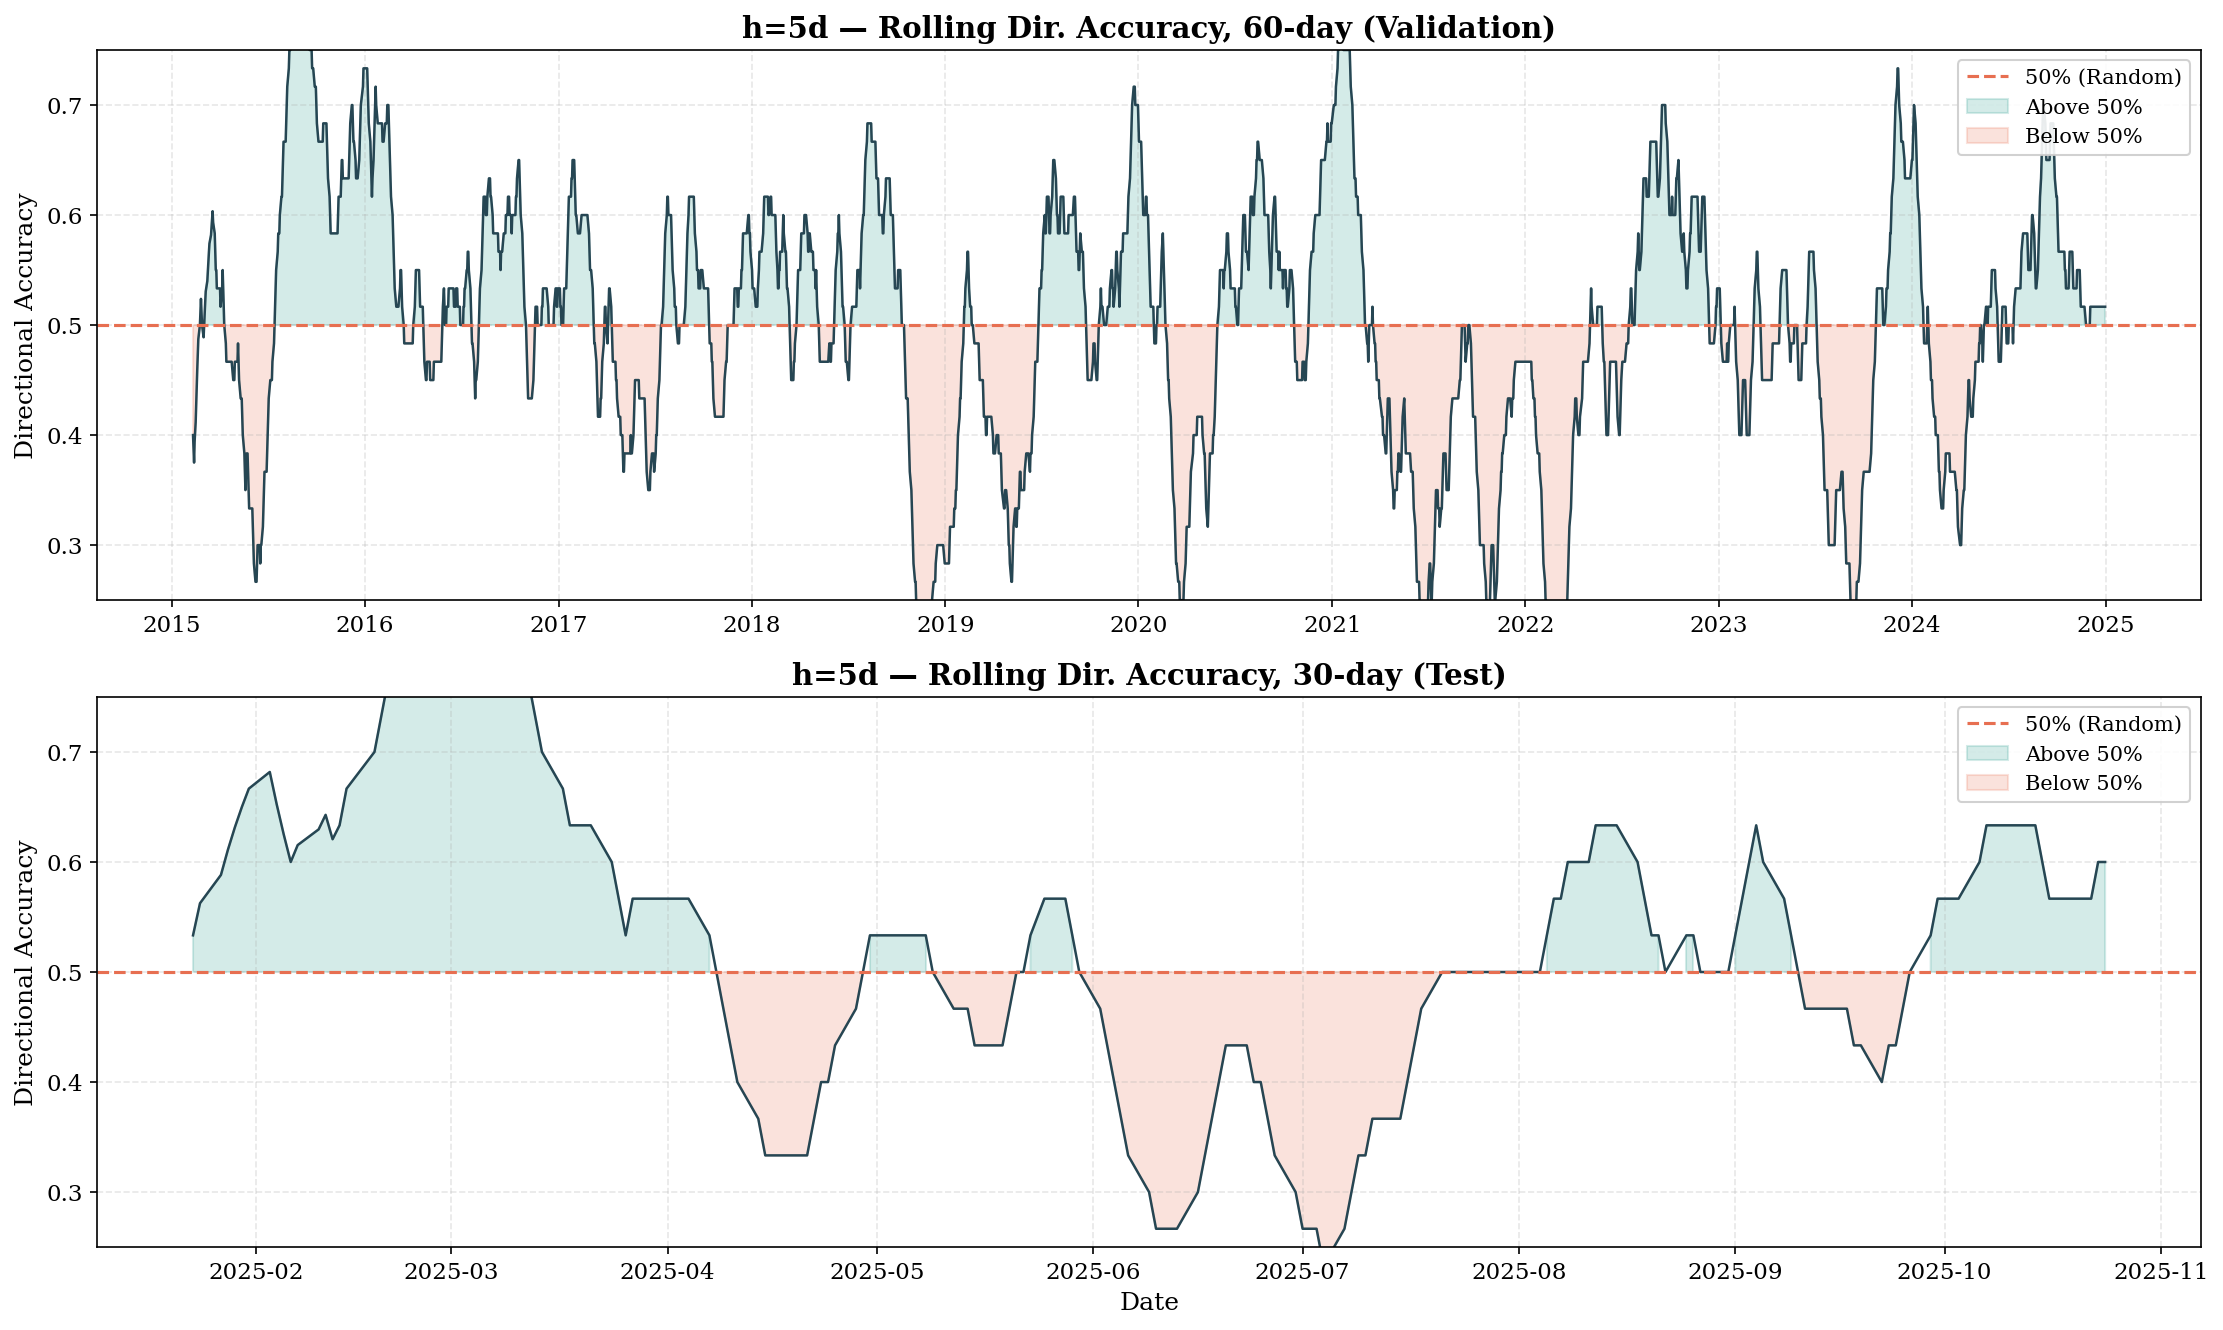

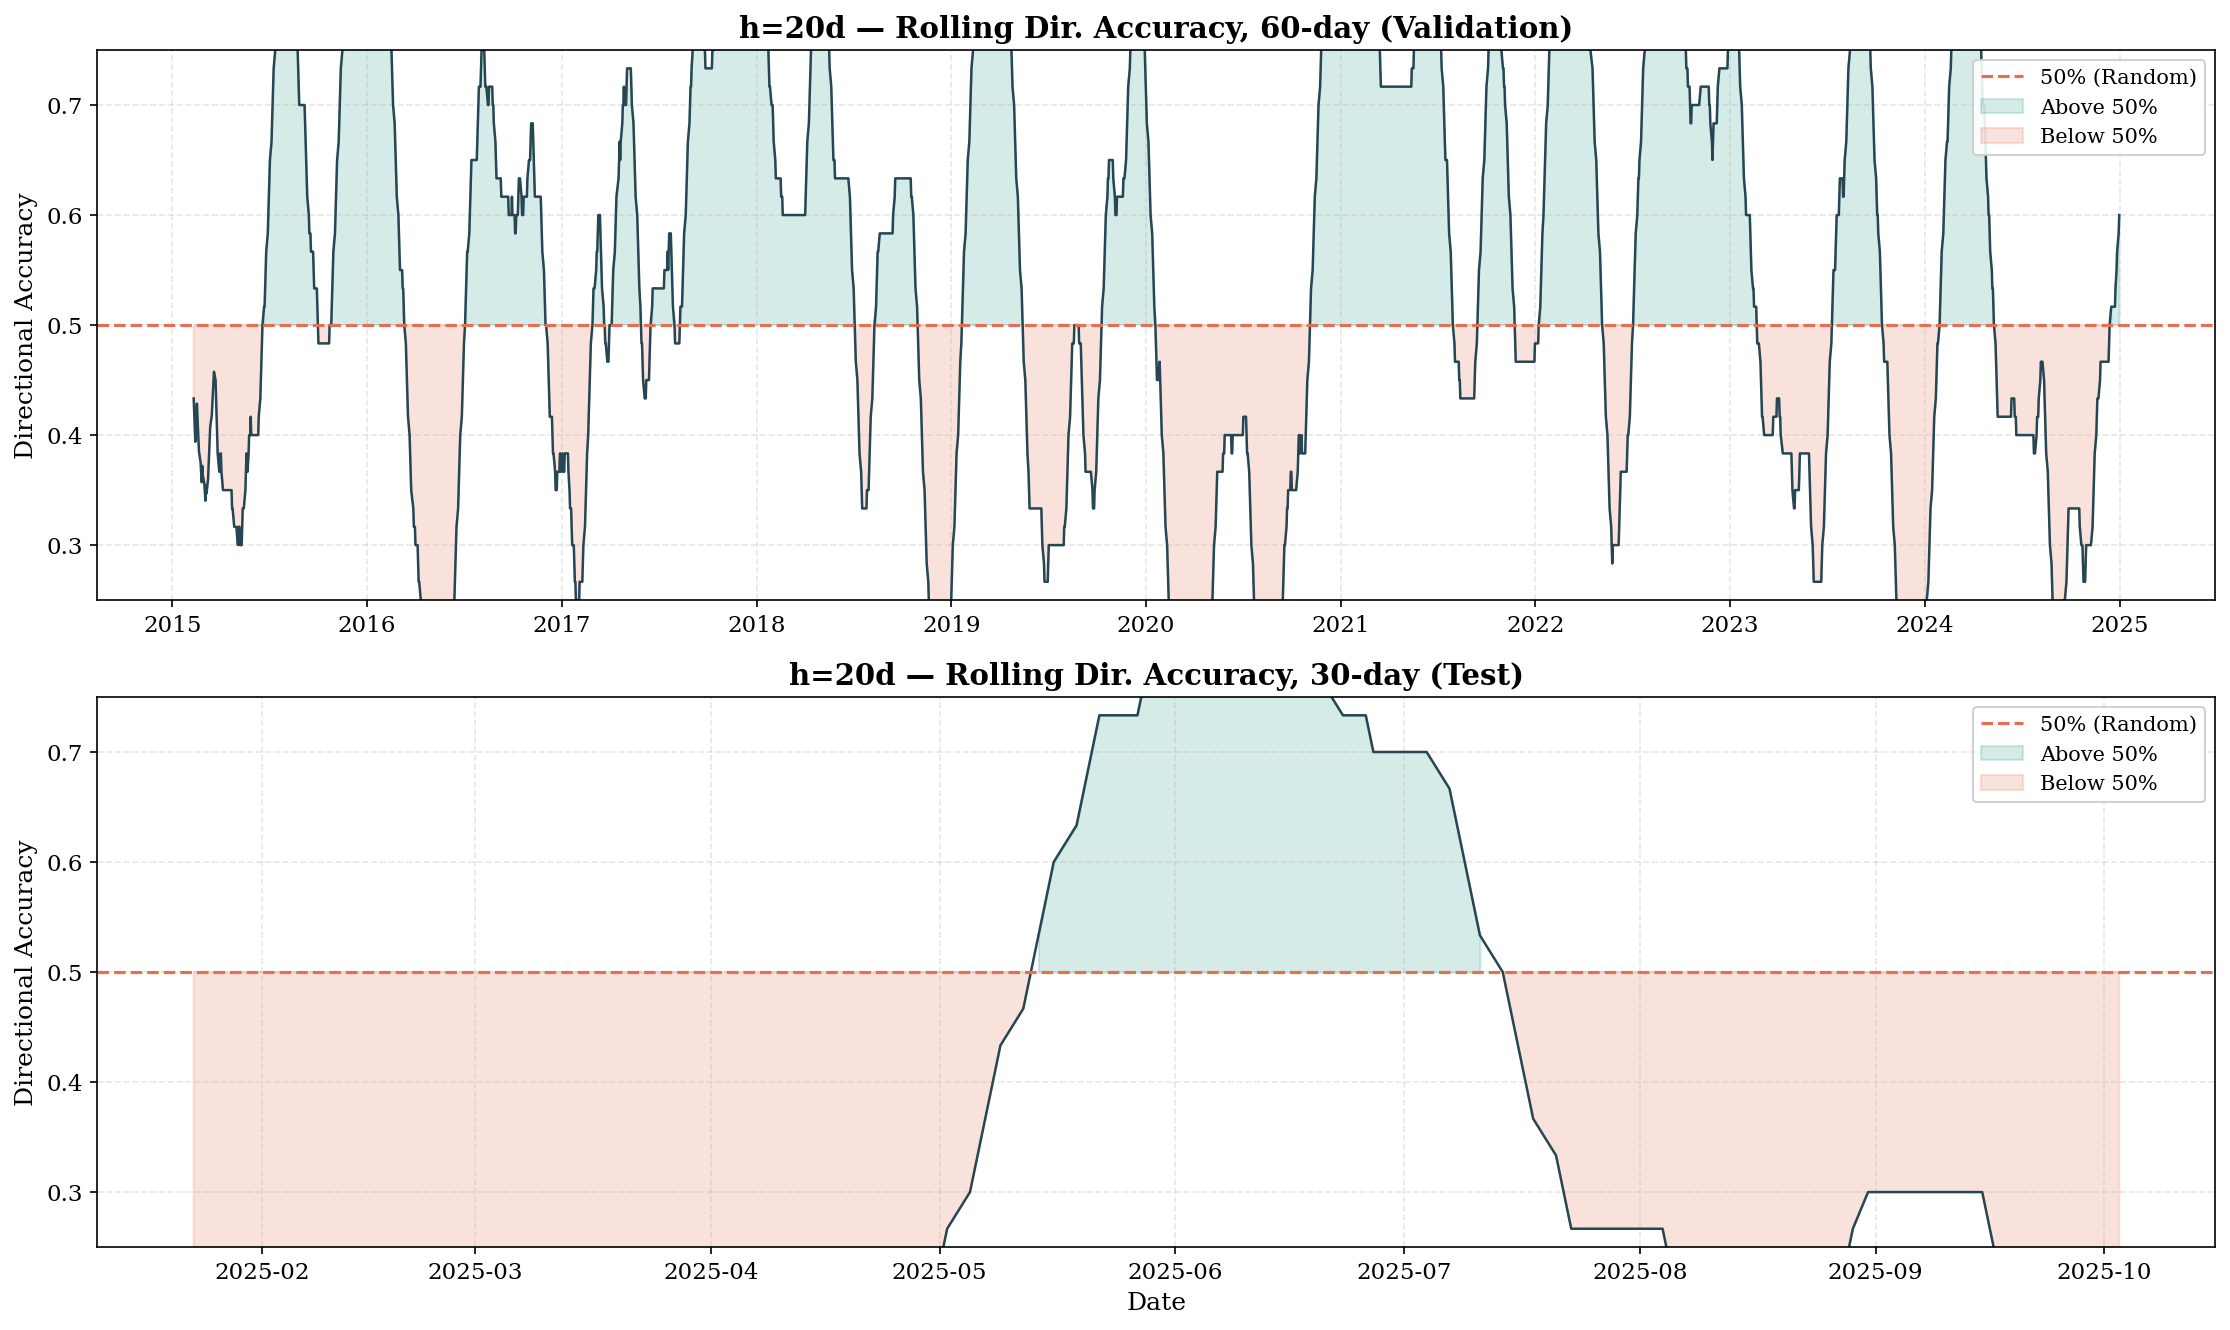

In [11]:
# ============================================================
# CELL 9: Rolling Directional Accuracy
# ============================================================

for h in HORIZONS:
    if h not in data: continue
    d = data[h]

    fig, axes = plt.subplots(2, 1, figsize=(15, 9))

    for ax, dates, y_true, y_pred, label, window in [
        (axes[0], d['dva'], d['yva'], d['pred_val'], 'Validation', 60),
        (axes[1], d['dte'], d['yte'], d['pred_test'], 'Test', min(30, len(d['yte'])//3)),
    ]:
        if len(y_true) < window:
            ax.text(0.5, 0.5, 'Not enough data', transform=ax.transAxes,
                    ha='center', fontsize=12)
            continue

        correct = (np.sign(y_true) == np.sign(y_pred)).astype(float)
        rolling = pd.Series(correct, index=dates).rolling(window, min_periods=window//2).mean()

        ax.plot(dates, rolling, color=COLORS['h1'], linewidth=1.2)
        ax.axhline(0.5, color=COLORS['neg'], linewidth=1.5, linestyle='--', label='50% (Random)')
        ax.fill_between(dates, rolling, 0.5, where=rolling > 0.5,
                        alpha=0.2, color=COLORS['pos'], label='Above 50%')
        ax.fill_between(dates, rolling, 0.5, where=rolling <= 0.5,
                        alpha=0.2, color=COLORS['neg'], label='Below 50%')
        ax.set_ylim(0.25, 0.75)
        ax.set_title(f'h={h}d — Rolling Dir. Accuracy, {window}-day ({label})', fontweight='bold')
        ax.set_ylabel('Directional Accuracy')
        ax.legend(loc='upper right', framealpha=0.9)

    axes[1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

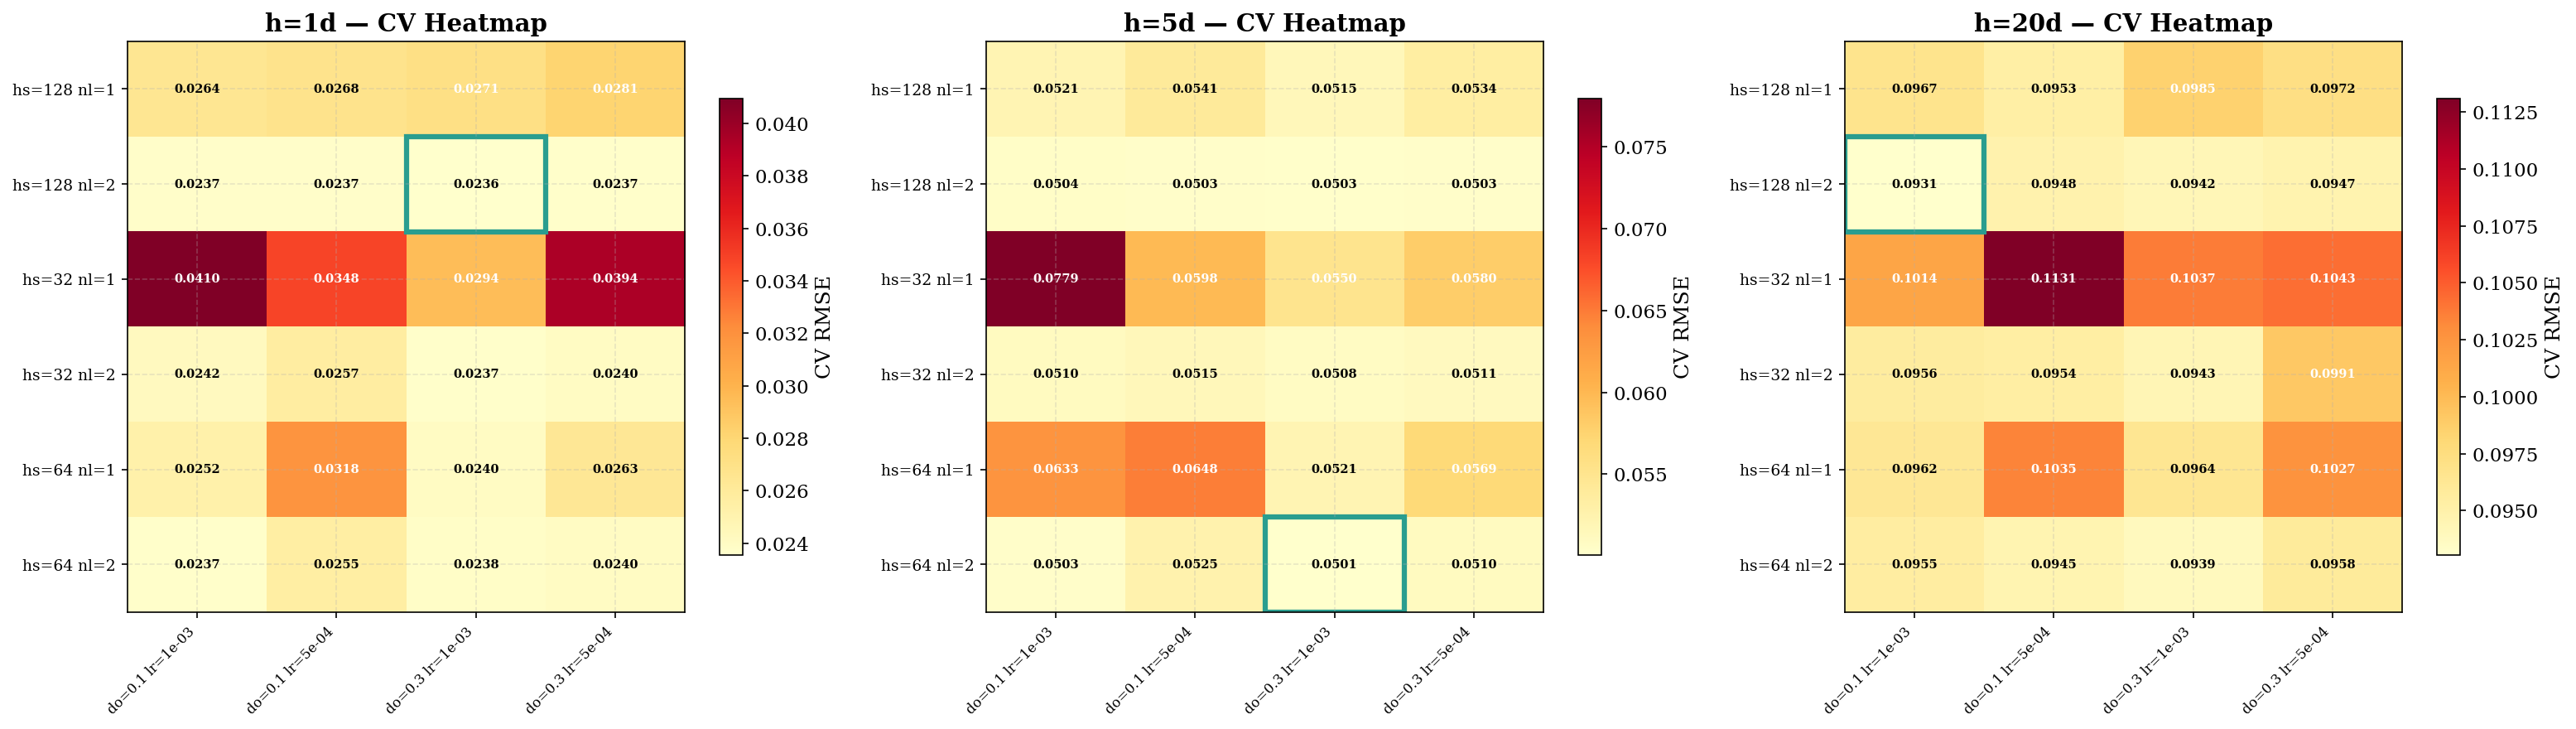

In [12]:
# ============================================================
# CELL 10: CV Heatmaps
# ============================================================

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(7 * len(HORIZONS), 6))
if len(HORIZONS) == 1: axes = [axes]

for ax, h in zip(axes, HORIZONS):
    if h not in data: continue
    cv_results = data[h]['state']['cv_results_']
    df = pd.DataFrame(cv_results)

    df['row'] = 'hs=' + df['hidden_size'].astype(str) + ' nl=' + df['num_layers'].astype(str)
    df['col'] = 'do=' + df['dropout'].astype(str) + ' lr=' + df['lr'].apply(lambda x: f'{x:.0e}')
    pivot = df.pivot(index='row', columns='col', values='cv_rmse')

    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            color = 'white' if val > pivot.values.mean() else 'black'
            ax.text(j, i, f'{val:.4f}', ha='center', va='center',
                    fontsize=7, color=color, fontweight='bold')

    best_idx = np.unravel_index(pivot.values.argmin(), pivot.values.shape)
    ax.add_patch(plt.Rectangle((best_idx[1]-0.5, best_idx[0]-0.5), 1, 1,
                                fill=False, edgecolor=COLORS['pos'], linewidth=3))

    plt.colorbar(im, ax=ax, label='CV RMSE', shrink=0.8)
    ax.set_title(f'h={h}d — CV Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

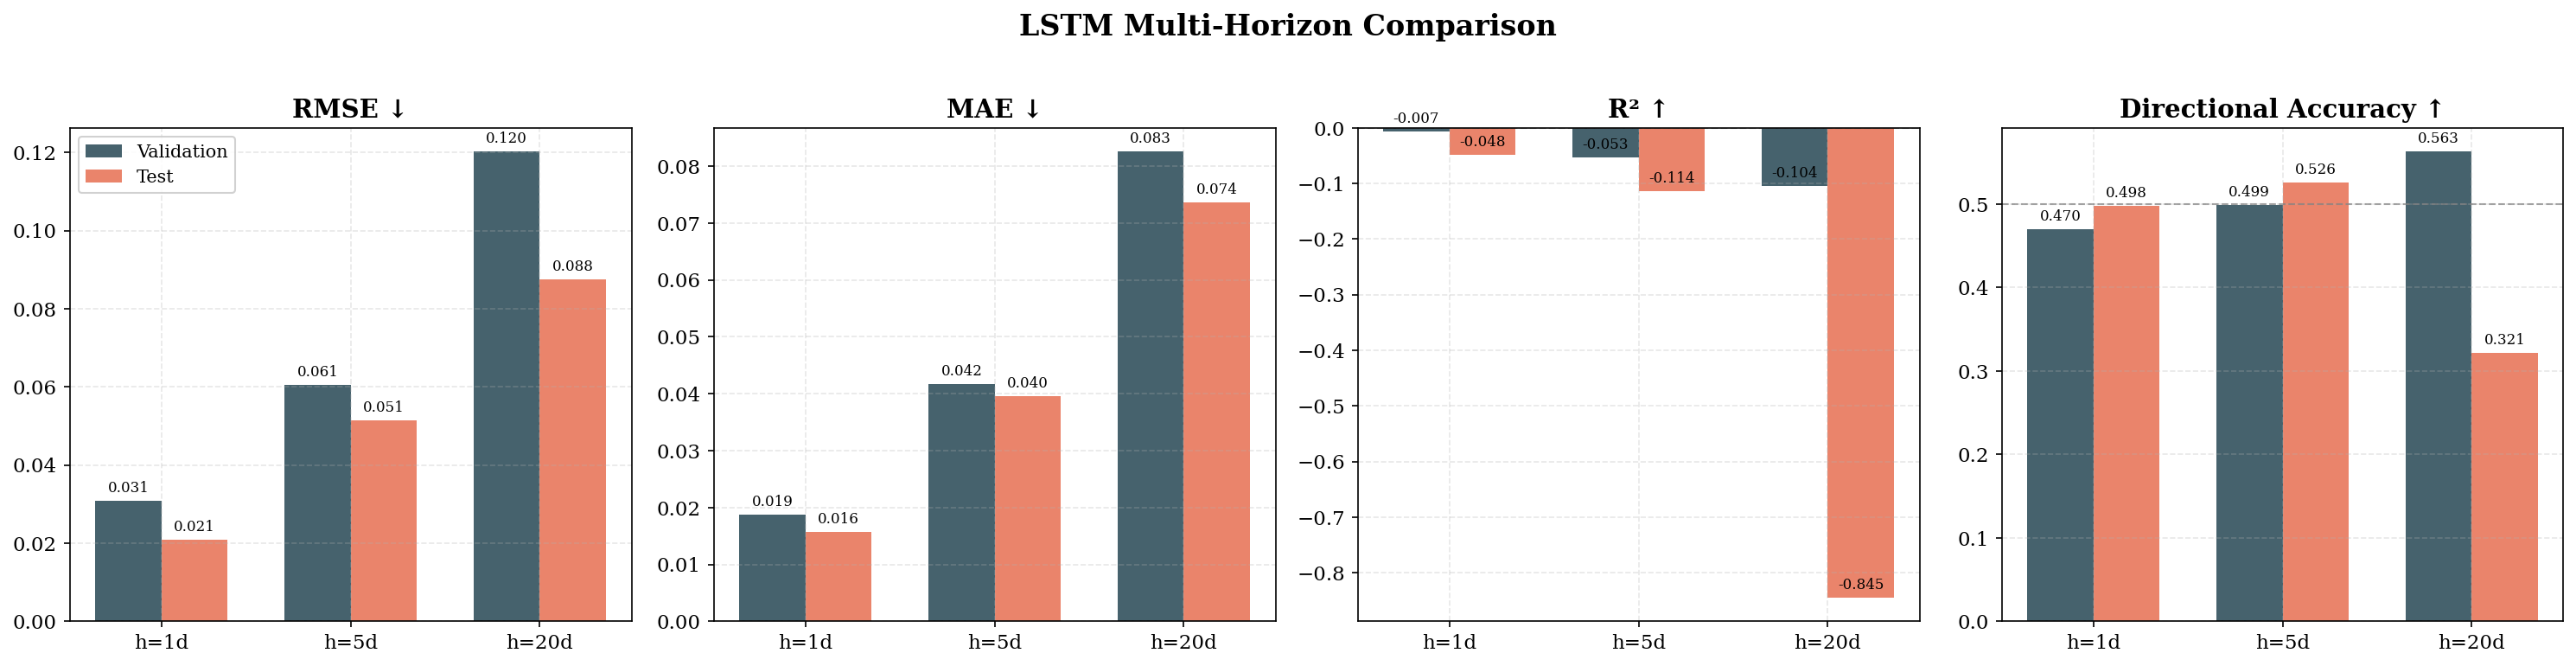

In [13]:
# ============================================================
# CELL 11: Multi-Horizon Comparison Bar Chart
# ============================================================

metrics_list = ['rmse', 'mae', 'r2', 'directional_acc']
titles = ['RMSE ↓', 'MAE ↓', 'R² ↑', 'Directional Accuracy ↑']

# Compute metrics
all_m = {}
for h in HORIZONS:
    if h not in data: continue
    d = data[h]
    all_m[h] = {
        'val':  {m: f(d['yva'], d['pred_val']) for m, f in
                 zip(metrics_list, [rmse, mae, r2, directional_accuracy])},
        'test': {m: f(d['yte'], d['pred_test']) for m, f in
                 zip(metrics_list, [rmse, mae, r2, directional_accuracy])},
    }

horizons = sorted(all_m.keys())
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.arange(len(horizons))
width = 0.35

for i, (metric, title) in enumerate(zip(metrics_list, titles)):
    ax = axes[i]
    val_vals  = [all_m[h]['val'][metric] for h in horizons]
    test_vals = [all_m[h]['test'][metric] for h in horizons]

    bars1 = ax.bar(x - width/2, val_vals, width, label='Validation',
                   color=COLORS['bar1'], alpha=0.85)
    bars2 = ax.bar(x + width/2, test_vals, width, label='Test',
                   color=COLORS['bar2'], alpha=0.85)

    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'h={h}d' for h in horizons])

    if metric == 'directional_acc':
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    elif metric == 'r2':
        ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

    for bar in list(bars1) + list(bars2):
        ht = bar.get_height()
        ax.annotate(f'{ht:.3f}', xy=(bar.get_x() + bar.get_width()/2, ht),
                   xytext=(0, 3), textcoords='offset points',
                   ha='center', va='bottom', fontsize=8)

    if i == 0:
        ax.legend(framealpha=0.9)

plt.suptitle('LSTM Multi-Horizon Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# CELL 12: Summary Metrics Table
# ============================================================

rows = []
for h in HORIZONS:
    if h not in all_m: continue
    for split in ['val', 'test']:
        m = all_m[h][split]
        rows.append({
            'Horizon': f'{h}d',
            'Split': split.title(),
            'RMSE': f"{m['rmse']:.6f}",
            'MAE': f"{m['mae']:.6f}",
            'R²': f"{m['r2']:.6f}",
            'Dir. Acc': f"{m['directional_acc']:.4f}",
        })

summary = pd.DataFrame(rows)
print('\n' + '='*65)
print('  LSTM Multi-Horizon Results Summary')
print('='*65)
print(summary.to_string(index=False))
print('='*65)

# Best configs
print('\nBest Hyperparameters:')
for h in HORIZONS:
    if h not in data: continue
    bp = data[h]['state']['best_params_']
    print(f"  h={h:>2}d: hs={bp['hidden_size']}, nl={bp['num_layers']}, "
          f"do={bp['dropout']}, lr={bp['lr']}, cv_rmse={bp['cv_rmse']:.6f}")


  LSTM Multi-Horizon Results Summary
Horizon Split     RMSE      MAE        R² Dir. Acc
     1d   Val 0.030974 0.018776 -0.006727   0.4702
     1d  Test 0.020988 0.015738 -0.047918   0.4977
     5d   Val 0.060561 0.041778 -0.053325   0.4987
     5d  Test 0.051399 0.039580 -0.113966   0.5261
    20d   Val 0.120319 0.082617 -0.103899   0.5632
    20d  Test 0.087591 0.073590 -0.845068   0.3214

Best Hyperparameters:
  h= 1d: hs=128, nl=2, do=0.3, lr=0.001, cv_rmse=0.023552
  h= 5d: hs=64, nl=2, do=0.3, lr=0.001, cv_rmse=0.050076
  h=20d: hs=128, nl=2, do=0.1, lr=0.001, cv_rmse=0.093050
